<div align="center">

## Fighting Barren Plateaus in Volatility Forecasting for Highly Liquid Assets

### Борьба с Barren Plateau при прогнозировании волатильности высоколиквидных активов (индекс МосБиржи, MOEX)
</div>

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import MinMaxScaler

import pennylane as qml
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

### Additional functions

In [2]:
def plot_decision_boundary(model, X, y, title, is_torch=False):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    if is_torch:
        with torch.no_grad():
            Z = model(torch.tensor(grid, dtype=torch.float32)).numpy()
    else:
        Z = model.predict_proba(grid)[:, 1]

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, levels=30, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=25, edgecolor="k")
    plt.title(title)
    plt.xlabel("key_rate (standardized)")
    plt.ylabel("inflation (standardized)")
    plt.tight_layout()
    plt.savefig(f"../graphics/{title.replace(' ', '_').replace(':', '')}.png", dpi=120)
    plt.show()

In [3]:
def training_plot(losses: list, title='VQC Training Progress'):
    plt.figure(figsize=(7,5))
    plt.plot(range(1, len(losses) + 1), losses, 'b-', linewidth=2, label='Training Loss')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)

### Quantum Hybrid Models

Добавлен параметр `encoding`, позволяющий переключаться между **Angle Encoding** и **IQP Encoding** без изменения остальной архитектуры. Это нужно для научного вклада статьи - сравнения способа кодирования реальных макроэкономических индикаторов (ключевая ставка ЦБ РФ, инфляция).

**Angle Encoding:** 
<br> 
$|\psi_0\rangle = \bigotimes_i R_Y(x_i)|0\rangle$ — каждый признак становится углом поворота своего кубита; лишние кубиты при нехватке признаков остаются нетронутыми (`AngleEmbedding` умеет работать при `len(inputs) <= n_qubits`).

**IQP Encoding:** 
<br>
$U_{\text{IQP}}(x) = \prod_{i<j} e^{-i x_i x_j Z_i Z_j} \prod_i e^{-i x_i Z_i} \bigotimes_i H|0\rangle$ — добавляет двухкубитные взаимодействия между парами признаков; в PennyLane `IQPEmbedding` требует **строгого равенства** числа признаков числу кубитов (в отличие от `AngleEmbedding`, автоматического дополнения нулями здесь нет), поэтому для IQP всегда нужен явный `expand_features_for_qubits`.

#### Variational Quantum Classifier

In [4]:
class VQC(nn.Module):
    def __init__(self, n_qubits=2, encoding="angle", dev_name="default.qubit"):
        super(VQC, self).__init__()
        self.n_qubits = n_qubits
        self.encoding = encoding
        self.dev = qml.device(dev_name, wires=self.n_qubits)

        # Квантовая схема
        @qml.qnode(self.dev, interface="torch")
        def quantum_circuit(inputs, weights):
            if encoding == "angle":
                qml.AngleEmbedding(inputs, wires=range(self.n_qubits)) # каждый признак -> угол вращения
            elif encoding == "iqp":
                qml.IQPEmbedding(inputs, wires=range(self.n_qubits), n_repeats=2) # + двухкубитные взаимодействия признаков
            else:
                raise ValueError("encoding must be 'angle' or 'iqp'")
            qml.StronglyEntanglingLayers(weights, wires=range(self.n_qubits)) # Ansatz (вариационная схема): аналог скрытых слоев нейросети
            return qml.expval(qml.PauliZ(0))

        weight_shapes = {"weights": (2, self.n_qubits, 3)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes) # Оборачивание в PyTorch слой

        self.model = nn.Sequential(
            self.quantum_layer,
            nn.Sigmoid() # Вероятность класса
        )

    def forward(self, x):
        return self.model(x).squeeze()

    def fit(self, X_train, y_train, epochs=150):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.1)
        loss_fn = torch.nn.BCELoss()

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)

        self.model.train()
        losses = []
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = self.model(X_train_t).squeeze()
            loss = loss_fn(preds, y_train_t)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return losses

    def predict(self, X_test):
        self.model.eval()
        with torch.no_grad():
            preds = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
            y_pred = (preds > 0.5).int().numpy()

        return y_pred

    def predict_proba(self, X_test):
        self.model.eval()
        with torch.no_grad():
            probs = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
        probs = probs.numpy()
        return np.column_stack([1 - probs, probs])


    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return (y_pred == y_test).mean()

#### Hybrid Variational Quantum Classifier

In [5]:
class VQC_hybrid(nn.Module):
    def __init__(self, n_qubits=2, n_layers=3, encoding="angle", dev_name='default.qubit'):
        super(VQC_hybrid, self).__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.encoding = encoding

        self.dev = qml.device(dev_name, wires=n_qubits)

        @qml.qnode(self.dev, interface="torch")
        def quantum_circuit(inputs, weights):
            if encoding == "angle":
                qml.AngleEmbedding(inputs, wires=range(self.n_qubits)) # каждый признак -> угол вращения
            elif encoding == "iqp":
                qml.IQPEmbedding(inputs, wires=range(self.n_qubits), n_repeats=2)
            else:
                raise ValueError("encoding must be 'angle' or 'iqp'")
            qml.StronglyEntanglingLayers(weights, wires=range(self.n_qubits)) # Ansatz (вариационная схема)
            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

        weight_shapes = {"weights": (self.n_layers, self.n_qubits, 3)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        # Гибрид: квантовый слой + классический линейный слой
        self.model = nn.Sequential(
            self.quantum_layer,
            nn.Linear(n_qubits, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze()

    def fit(self, X_train, y_train, epochs=150):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.1)
        loss_fn = torch.nn.BCELoss()

        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)

        self.model.train()
        losses = []
        for _ in range(epochs):
            optimizer.zero_grad()
            preds = self.model(X_train_t).squeeze()
            loss = loss_fn(preds, y_train_t)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return losses


    def predict(self, X_test):
        self.model.eval()
        with torch.no_grad():
            preds = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
            y_pred = (preds > 0.5).int().numpy()

        return y_pred

    def predict_proba(self, X_test):
        self.model.eval()
        with torch.no_grad():
            probs = self.model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
        probs = probs.numpy()
        return np.column_stack([1 - probs, probs])

    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return (y_pred == y_test).mean()

### Create function for compute gradients

In [6]:
def compute_gradients(model, X, y, loss_fn=None):
    if loss_fn is None:
        loss_fn = torch.nn.BCELoss()

    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)

    # Включаем градиенты
    model.train()

    # Сброс градиентов
    for p in model.parameters():
        if p.grad is not None:
            p.grad.zero_()

    # Прямой проход и вычисление loss
    preds = model(X_t).squeeze()
    loss = loss_fn(preds, y_t)

    # Обратное распространение
    loss.backward()

    # Собираем градиенты
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.detach().view(-1))

    grads = torch.cat(grads)
    grad_norm = torch.norm(grads).item()
    grad_var = torch.var(grads).item()

    return grads.numpy(), grad_norm, grad_var

### Creating Data

In [7]:
results = []

**Котировки — MOEX ISS API**

In [8]:
import requests
import apimoex
import pandas as pd



with requests.Session() as session:

    # Индекс МосБиржи (IMOEX)
    data = apimoex.get_board_history(
        session,
        security="IMOEX",
        start="2019-01-01",
        board="SNDX",     # индексный борд
        market="index",
        engine="stock",
    )


quotes = pd.DataFrame(data)
quotes["TRADEDATE"] = pd.to_datetime(quotes["TRADEDATE"])
quotes = quotes.set_index("TRADEDATE")
quotes = quotes[["CLOSE"]].rename(columns={"CLOSE": "close"})
quotes["ret"] = quotes["close"].pct_change()

print(quotes.head())
print(quotes.tail())

quotes.to_csv("../data/quotes_raw.csv")

              close       ret
TRADEDATE                    
2019-01-03  2375.60       NaN
2019-01-04  2406.50  0.013007
2019-01-08  2389.69 -0.006985
2019-01-09  2414.13  0.010227
2019-01-10  2434.15  0.008293
              close       ret
TRADEDATE                    
2026-08-10  2293.32  0.005265
2026-08-11  2323.82  0.013299
2026-08-12  2301.43 -0.009635
2026-08-13  2232.14 -0.030107
2026-08-14  2136.35 -0.042914


**Ключевая ставка + инфляция — сайт ЦБ РФ**

In [9]:
url = "https://cbr.ru/hd_base/infl/"
params = "?UniDbQuery.Posted=True&UniDbQuery.From=01.01.2019&UniDbQuery.To=31.12.2025"

tables = pd.read_html(url + params)
macro = tables[0]  # первая таблица на странице

macro.columns = ["date_raw", "key_rate", "inflation", "inflation_target"]
macro["date"] = pd.to_datetime(macro["date_raw"].apply(lambda x: f"{x:.4f}"), format="%m.%Y")
macro = macro.set_index("date").sort_index()

print(macro.head())
macro.to_csv("../data/macro_raw.csv")

            date_raw  key_rate  inflation  inflation_target
date                                                       
2019-01-01    1.2019       775        500               400
2019-02-01    2.2019       775        520               400
2019-03-01    3.2019       775        530               400
2019-04-01    4.2019       775        520               400
2019-05-01    5.2019       775        510               400


In [10]:
quotes = pd.read_csv("../data/quotes_raw.csv", index_col=0, parse_dates=True)
macro = pd.read_csv("../data/macro_raw.csv", index_col=0, parse_dates=True)

# растягиваем месячные макро-значения на дневную сетку котировок
macro_daily = macro.reindex(quotes.index, method="ffill")

data = quotes.join(macro_daily)
data = data.dropna()

# ключевая ставка и инфляция на cbr.ru отдаются в процентах x100 (775 = 7.75%)
data["key_rate"] = data["key_rate"] / 100.0
data["inflation"] = data["inflation"] / 100.0
data["inflation_target"] = data["inflation_target"] / 100.0

data.to_csv("../data/data.csv")
data.head(10)

,close,ret,date_raw,key_rate,inflation,inflation_target
TRADEDATE,,,,,,
2019-01-04,2406.50,0.013007,1.2019,7.75,5.0,4.0
2019-01-08,2389.69,-0.006985,1.2019,7.75,5.0,4.0
2019-01-09,2414.13,0.010227,1.2019,7.75,5.0,4.0
2019-01-10,2434.15,0.008293,1.2019,7.75,5.0,4.0
2019-01-11,2444.45,0.004231,1.2019,7.75,5.0,4.0
2019-01-14,2440.15,-0.001759,1.2019,7.75,5.0,4.0
2019-01-15,2439.55,-0.000246,1.2019,7.75,5.0,4.0
2019-01-16,2434.60,-0.002029,1.2019,7.75,5.0,4.0
2019-01-17,2447.64,0.005356,1.2019,7.75,5.0,4.0


### Concept Drift Diagnostics

Ключевая гипотеза статьи — **Concept Drift, характерный для российского рынка (резкие циклы изменения ключевой ставки ЦБ РФ), ускоряет наступление Barren Plateau**. Чтобы проверить эту гипотезу, необходимо количественно измерить дрейф распределения макропризнаков во времени и разбить выборку на участки с низким и высоким уровнем дрейфа.

Дрейф измеряется через **Population Stability Index (PSI)** между соседними скользящими окнами по ключевой ставке и инфляции:

$$
\mathrm{PSI} = \sum_{i} (p_i^{curr} - p_i^{prev}) \cdot \ln\left(\frac{p_i^{curr}}{p_i^{prev}}\right)
$$

где $p_i^{prev}$, $p_i^{curr}$ — доли наблюдений в $i$-м бине гистограммы признака в предыдущем и текущем окне. Чем выше PSI, тем сильнее локальный дрейф распределения.

In [11]:
def build_features(df):
    df = df.copy()
    df["real_vol_10"] = df["ret"].rolling(10).std() * np.sqrt(252)
    df["mom_5"] = df["close"].pct_change(5)
    df["ret_lag1"] = df["ret"].shift(1)
    df["fwd_vol_5"] = df["ret"].shift(-1).rolling(5).std().shift(-4) * np.sqrt(252)
    df = df.dropna()
    thr = df["fwd_vol_5"].median()
    df["y_high_vol"] = (df["fwd_vol_5"] > thr).astype(int)
    return df


def psi(a, b, bins=10):
    edges = np.histogram_bin_edges(np.concatenate([a, b]), bins=bins)
    pa, _ = np.histogram(a, bins=edges)
    pb, _ = np.histogram(b, bins=edges)
    pa = pa / pa.sum() + 1e-6
    pb = pb / pb.sum() + 1e-6
    return float(np.sum((pa - pb) * np.log(pa / pb)))


def compute_drift_series(df, window=60, step=20):
    idx, scores = [], []
    kr, infl = df["key_rate"].values, df["inflation"].values
    for i in range(2 * window, len(df), step):
        d = psi(kr[i-2*window:i-window], kr[i-window:i]) + \
            psi(infl[i-2*window:i-window], infl[i-window:i])
        idx.append(df.index[i]); scores.append(d)
    return pd.Series(scores, index=idx)


df_raw = pd.read_csv("../data/data.csv", index_col=0, parse_dates=True)
df_features = build_features(df_raw)

drift_series = compute_drift_series(df_raw, window=60, step=20)
drift_full = drift_series.reindex(df_features.index, method="nearest")
df_features["drift_score"] = drift_full.values

print(df_features.shape)
print(df_features["y_high_vol"].value_counts())

(1897, 12)
y_high_vol
0    949
1    948
Name: count, dtype: int64


In [12]:
df_features[["key_rate", "inflation", "real_vol_10", "mom_5", "ret_lag1", "drift_score", "y_high_vol"]].describe()

,key_rate,inflation,real_vol_10,mom_5,ret_lag1,drift_score,y_high_vol
count,1897.000000,1897.000000,1897.000000,1897.000000,1897.000000,1897.000000,1897.000000
mean,11.258434,7.140269,0.193002,0.000509,0.000111,29.222107,0.499736
std,5.658025,3.411567,0.178943,0.036004,0.016526,11.130803,0.500132
min,4.250000,2.300000,0.035949,-0.435576,-0.332806,0.000000,0.000000
25%,6.500000,4.700000,0.107270,-0.014932,-0.005646,21.249031,0.000000
50%,8.000000,6.500000,0.151486,0.003266,0.000796,29.997161,0.000000
75%,16.000000,8.790000,0.224513,0.018243,0.006879,38.087742,1.000000
max,21.000000,17.830000,2.194685,0.170238,0.200358,52.418892,1.000000


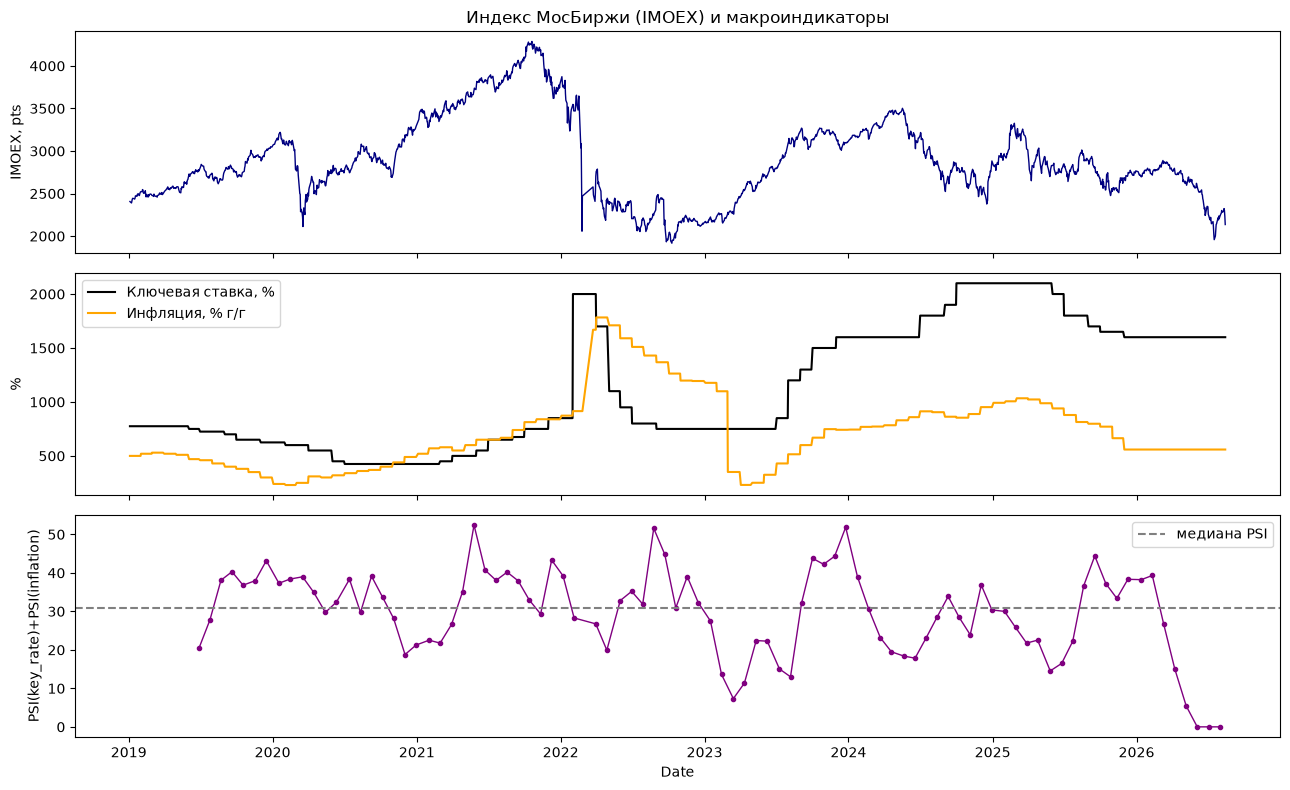

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df_raw.index, df_raw["close"], color="navy", linewidth=1)
axes[0].set_ylabel("IMOEX, pts")
axes[0].set_title("Индекс МосБиржи (IMOEX) и макроиндикаторы")

axes[1].plot(df_raw.index, df_raw["key_rate"] * 100, color="black", label="Ключевая ставка, %")
axes[1].plot(df_raw.index, df_raw["inflation"] * 100, color="orange", label="Инфляция, % г/г")
axes[1].set_ylabel("%")
axes[1].legend(loc="upper left")

axes[2].plot(drift_series.index, drift_series.values, marker="o", markersize=3, linewidth=1, color="purple")
axes[2].axhline(drift_series.median(), linestyle="--", color="gray", label="медиана PSI")
axes[2].set_ylabel("PSI(key_rate)+PSI(inflation)")
axes[2].set_xlabel("Date")
axes[2].legend()

plt.tight_layout()
plt.savefig("../graphics/market_and_drift_overview.png", dpi=120)
plt.show()

### Regime Split: NoDrift vs WithDrift

Выборка разбивается по PSI-метрике дрейфа на два поднабора: `NoDrift` (нижние 40% по PSI — относительно стабильные участки истории) и `WithDrift` (верхние 40% по PSI — участки, примыкающие к сменам режима ключевой ставки). Далее эти два поднабора используются везде вместо `Circles`/`Moons` из предыдущей статьи, а базовыми признаками для кодирования служат **ключевая ставка ЦБ РФ и инфляция** — ровно те макроиндикаторы, сравнение кодирования которых требуется по заданию.

In [14]:
q40 = df_features["drift_score"].quantile(0.4)
q60 = df_features["drift_score"].quantile(0.6)

no_drift_df = df_features[df_features["drift_score"] <= q40]
with_drift_df = df_features[df_features["drift_score"] >= q60]

print("NoDrift:", no_drift_df.shape, "mean PSI =", no_drift_df["drift_score"].mean())
print("WithDrift:", with_drift_df.shape, "mean PSI =", with_drift_df["drift_score"].mean())

N_SAMPLE = 300
regime_frames = {"NoDrift": no_drift_df, "WithDrift": with_drift_df}
regime_data = {}

for regime_name, sub in regime_frames.items():
    sub = sub.sample(n=min(N_SAMPLE, len(sub)), random_state=42).sort_index()

    X_base = sub[["key_rate", "inflation"]].values
    y = sub["y_high_vol"].values

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_base, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    regime_data[regime_name] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "drift_local_mean": sub["drift_score"].mean()
    }

X_NoDrift_train, X_NoDrift_test = regime_data["NoDrift"]["X_train"], regime_data["NoDrift"]["X_test"]
y_NoDrift_train, y_NoDrift_test = regime_data["NoDrift"]["y_train"], regime_data["NoDrift"]["y_test"]

X_WithDrift_train, X_WithDrift_test = regime_data["WithDrift"]["X_train"], regime_data["WithDrift"]["X_test"]
y_WithDrift_train, y_WithDrift_test = regime_data["WithDrift"]["y_train"], regime_data["WithDrift"]["y_test"]

NoDrift: (769, 12) mean PSI = 18.18620557299365
WithDrift: (760, 12) mean PSI = 39.83695333808655


### Variational Quantum Classifiers

Как и в прошлой статье, наивный базовый эксперимент подаёт на вход всего 2 признака (`key_rate`, `inflation`) независимо от числа кубитов — `AngleEmbedding` при нехватке признаков просто не поворачивает лишние кубиты. Это демонстрирует деградацию качества "по умолчанию", ещё до того как вводится осмысленное расширение признаков (см. раздел "Feature Preparation for Quantum Circuits").

**NoDrift**

In [15]:
qubits = [2, 4, 6, 8, 10]

for q in qubits:
    vqc_no_drift = VQC(n_qubits=q, encoding="angle")

    losses = vqc_no_drift.fit(X_NoDrift_train, y_NoDrift_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_no_drift, X_NoDrift_train, y_NoDrift_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC",
        "Dataset": "NoDrift",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

**WithDrift**

In [16]:
qubits = [2, 4, 6, 8, 10]

for q in qubits:
    vqc_with_drift = VQC(n_qubits=q, encoding="angle")

    losses = vqc_with_drift.fit(X_WithDrift_train, y_WithDrift_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_with_drift, X_WithDrift_train, y_WithDrift_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC",
        "Dataset": "WithDrift",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

### Hybrid Variational Quantum Classifiers

**NoDrift**

In [17]:
qubits = [2, 4, 6, 8, 10]

for q in qubits:
    vqc_hybrid_no_drift = VQC_hybrid(n_qubits=q, encoding="angle")

    losses = vqc_hybrid_no_drift.fit(X_NoDrift_train, y_NoDrift_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_hybrid_no_drift, X_NoDrift_train, y_NoDrift_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC_hybrid",
        "Dataset": "NoDrift",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

**WithDrift**

In [18]:
qubits = [2, 4, 6, 8, 10]

for q in qubits:
    vqc_hybrid_with_drift = VQC_hybrid(n_qubits=q, encoding="angle")

    losses = vqc_hybrid_with_drift.fit(X_WithDrift_train, y_WithDrift_train)

    grads, grad_norm, grad_var = compute_gradients(vqc_hybrid_with_drift, X_WithDrift_train, y_WithDrift_train)
    grad_mean = grads.mean()

    results.append({
        "Model": "VQC_hybrid",
        "Dataset": "WithDrift",
        "n_qubits": q,
        "Hidden_Layers": None,
        "Loss_final": losses[-1],
        "Gradient_Norm": grad_norm,
        "Gradient_Variance": grad_var,
        "Gradient_Mean": grad_mean
    })

### MLP

**NoDrift**

In [19]:
mlp_configs = [
    [8, 8],      # 2 слоя по 8 нейронов
    [16, 16],    # 2 слоя по 16 нейронов
    [32, 32]     # 2 слоя по 32 нейронов
]


for config in mlp_configs:
    mlp_no_drift = MLPClassifier(hidden_layer_sizes=tuple(config), max_iter=150, random_state=42)
    mlp_no_drift.fit(X_NoDrift_train, y_NoDrift_train)

    y_pred = mlp_no_drift.predict(X_NoDrift_test)

    results.append({
        "Model": "MLP",
        "Dataset": "NoDrift",
        "n_qubits": None,
        "Hidden_Layers": str(config),
        "Loss_final": mlp_no_drift.loss_,
        "Gradient_Norm": None,
        "Gradient_Variance": None,
        "Gradient_Mean": None
    })

/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


**WithDrift**

In [20]:
mlp_configs = [
    [8, 8],      # 2 слоя по 8 нейронов
    [16, 16],    # 2 слоя по 16 нейронов
    [32, 32]     # 2 слоя по 32 нейронов
]


for config in mlp_configs:
    mlp_with_drift = MLPClassifier(hidden_layer_sizes=tuple(config), max_iter=150, random_state=42)
    mlp_with_drift.fit(X_WithDrift_train, y_WithDrift_train)

    y_pred = mlp_with_drift.predict(X_WithDrift_test)

    results.append({
        "Model": "MLP",
        "Dataset": "WithDrift",
        "n_qubits": None,
        "Hidden_Layers": str(config),
        "Loss_final": mlp_with_drift.loss_,
        "Gradient_Norm": None,
        "Gradient_Variance": None,
        "Gradient_Mean": None
    })

/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


### Analysis of the results

In [21]:
df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    by=["Dataset"]
)

df_results

,Model,Dataset,n_qubits,Hidden_Layers,Loss_final,Gradient_Norm,Gradient_Variance,Gradient_Mean
0,VQC,NoDrift,2.0,NaN,0.609106,0.000004,1.253381e-12,-2.455488e-07
22,MLP,NoDrift,NaN,"[32, 32]",0.584492,NaN,NaN,NaN
21,MLP,NoDrift,NaN,"[16, 16]",0.602822,NaN,NaN,NaN
20,MLP,NoDrift,NaN,"[8, 8]",0.626340,NaN,NaN,NaN
14,VQC_hybrid,NoDrift,10.0,NaN,0.562559,0.042836,1.758225e-05,-8.712398e-04
13,VQC_hybrid,NoDrift,8.0,NaN,0.565717,0.016642,3.412021e-06,2.222446e-04
11,VQC_hybrid,NoDrift,4.0,NaN,0.564111,0.020122,9.815416e-06,-5.468895e-04
10,VQC_hybrid,NoDrift,2.0,NaN,0.565266,0.001578,1.219136e-07,-4.994971e-05
12,VQC_hybrid,NoDrift,6.0,NaN,0.563874,0.029165,1.389776e-05,5.241398e-04
1,VQC,NoDrift,4.0,NaN,0.638004,0.000358,4.949203e-09,2.436578e-05


### Additional Diagnostics for Barren Plateaus

На предыдущем этапе были обучены базовые модели `VQC`, `VQC_hybrid` и `MLP`, а также сохранены итоговые значения функции потерь и градиентов. Однако для анализа Barren Plateaus недостаточно смотреть только на финальную норму градиента. Необходимо отслеживать динамику обучения по эпохам: изменение функции потерь, нормы градиента и дисперсии градиента.

Проблема Barren Plateaus проявляется в том, что градиенты параметров вариационной квантовой схемы становятся исчезающе малыми при росте числа кубитов, из-за чего оптимизация практически останавливается.

### Feature Preparation for Quantum Circuits

Исходные признаки `key_rate` и `inflation` — только два макроиндикатора. При этом в эксперименте используются квантовые схемы с 2, 4 и 8 кубитами. Если число признаков меньше числа кубитов, часть кубитов не получает содержательного входного сигнала. Это может дополнительно ухудшать обучение и усиливать эффект деградации при увеличении числа кубитов.

Поэтому добавим отдельную функцию подготовки признаков. Она расширяет двумерное пространство (`key_rate`, `inflation`) до нужного числа кубитов с помощью нелинейных преобразований — точно так же, как в предыдущей статье расширялись координаты `Circles`/`Moons`.

In [22]:
def expand_features_for_qubits(X, n_qubits):
    x1 = X[:, 0]  # key_rate (standardized)
    x2 = X[:, 1]  # inflation (standardized)

    features = [
        x1,
        x2,
        x1 ** 2,
        x2 ** 2,
        x1 * x2,
        np.sqrt(x1 ** 2 + x2 ** 2),
        np.sin(x1),
        np.cos(x1),
        np.sin(x2),
        np.cos(x2)
    ]

    X_new = np.column_stack(features)

    if X_new.shape[1] < n_qubits:
        repeat_count = int(np.ceil(n_qubits / X_new.shape[1]))
        X_new = np.tile(X_new, (1, repeat_count))

    return X_new[:, :n_qubits]


def prepare_quantum_features(X_train, X_test, n_qubits):
    X_train_expanded = expand_features_for_qubits(X_train, n_qubits)
    X_test_expanded = expand_features_for_qubits(X_test, n_qubits)

    scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))

    X_train_scaled = scaler.fit_transform(X_train_expanded)
    X_test_scaled = scaler.transform(X_test_expanded)

    return X_train_scaled, X_test_scaled

### Gradient Logging During Training

В старой реализации метод `fit` возвращает только значения функции потерь. Для анализа Barren Plateaus добавим отдельную функцию обучения, которая не меняет классы `VQC`, `VQC_hybrid` и `VQCAnsatz`, но позволяет сохранить расширенную информацию о градиентах.

Будем логировать следующие величины:

$$
\|\nabla C(\theta)\|_2 = \sqrt{\sum_{i=1}^{m}\left(\frac{\partial C(\theta)}{\partial \theta_i}\right)^2}
$$

где:

- $\|\nabla C(\theta)\|_2$ — евклидова норма градиента;
- $C(\theta)$ — функция потерь;
- $\theta_i$ — параметры квантовой схемы;
- $m$ — общее число параметров.

In [23]:
def get_grad_stats(model):
    grads = []

    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.detach().flatten())

    if len(grads) == 0:
        return {
            "grad_norm": 0.0,
            "grad_var": 0.0,
            "grad_mean_abs": 0.0,
            "grad_max_abs": 0.0
        }

    grads = torch.cat(grads)

    return {
        "grad_norm": torch.norm(grads).item(),
        "grad_var": torch.var(grads).item(),
        "grad_mean_abs": torch.mean(torch.abs(grads)).item(),
        "grad_max_abs": torch.max(torch.abs(grads)).item()
    }


def fit_with_gradient_logging(model, X_train, y_train, epochs=150, lr=0.1, optimizer_name="adam"):
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError("optimizer_name must be 'adam' or 'sgd'")

    loss_fn = torch.nn.BCELoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)

    history = {
        "loss": [],
        "grad_norm": [],
        "grad_var": [],
        "grad_mean_abs": [],
        "grad_max_abs": []
    }

    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()

        preds = model(X_train_t).squeeze()
        loss = loss_fn(preds, y_train_t)

        loss.backward()

        grad_stats = get_grad_stats(model)

        optimizer.step()

        history["loss"].append(loss.item())
        history["grad_norm"].append(grad_stats["grad_norm"])
        history["grad_var"].append(grad_stats["grad_var"])
        history["grad_mean_abs"].append(grad_stats["grad_mean_abs"])
        history["grad_max_abs"].append(grad_stats["grad_max_abs"])

        if epoch % 50 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"loss={loss.item():.5f} | "
                f"grad_norm={grad_stats['grad_norm']:.3e} | "
                f"grad_var={grad_stats['grad_var']:.3e}"
            )

    return history

### Training Dynamics Visualization

Для диагностики Barren Plateaus построим три основных графика:

1. график функции потерь по эпохам;
2. график нормы градиента по эпохам;
3. график дисперсии градиента по эпохам.

Если модель попадает в Barren Plateau, то функция потерь выходит на плато, а значения нормы и дисперсии градиента падают до очень малых величин.

In [24]:
def plot_barren_plateau_diagnostics(history, title):
    epochs = np.arange(1, len(history["loss"]) + 1)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["loss"], linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss dynamics")
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["grad_norm"], linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Gradient norm")
    plt.yscale("log")
    plt.title("Gradient norm dynamics")
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["grad_var"], linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Gradient variance")
    plt.yscale("log")
    plt.title("Gradient variance dynamics")
    plt.grid(alpha=0.3)

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f"../graphics/diag_{title.replace(' ', '_').replace(':', '').replace(',', '')}.png", dpi=120)
    plt.show()

### Baseline VQC Diagnostics

Теперь повторим обучение базовой квантовой модели `VQC`, но уже с логированием градиентов по эпохам, и с корректным расширением признаков через `prepare_quantum_features`. Это не заменяет старый эксперимент, а добавляет к нему диагностический слой.

Особое внимание уделяется сравнению схем при $n = 2$, $n = 4$ и $n = 8$, где $n$ — число кубитов, на обоих режимах дрейфа: `NoDrift` и `WithDrift`.


Dataset: NoDrift | Model: VQC | Qubits: 2
Epoch 000 | loss=0.77163 | grad_norm=1.754e-01 | grad_var=2.603e-03
Epoch 050 | loss=0.60659 | grad_norm=4.097e-03 | grad_var=1.525e-06
Epoch 100 | loss=0.60637 | grad_norm=2.575e-04 | grad_var=5.597e-09


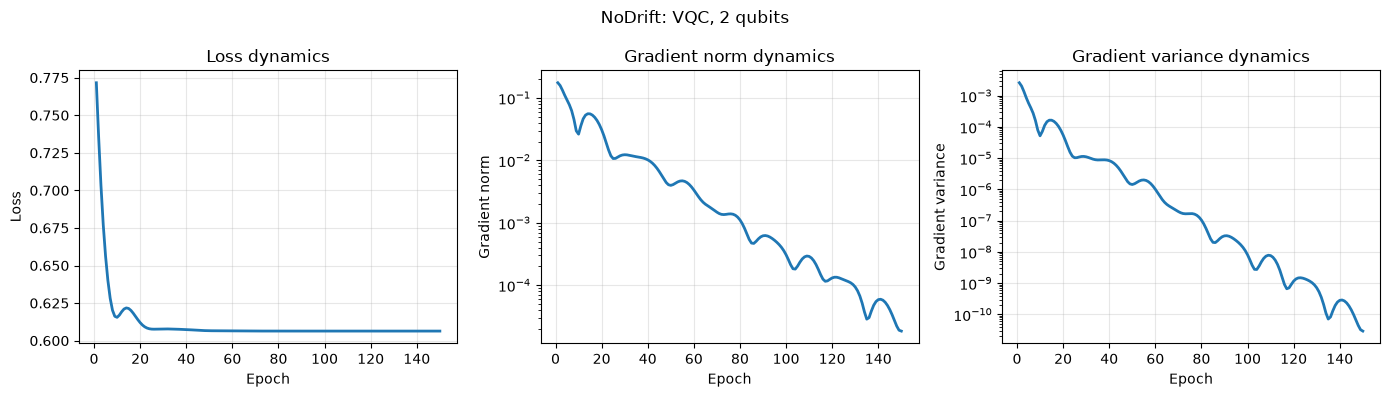


Dataset: NoDrift | Model: VQC | Qubits: 4
Epoch 000 | loss=0.68602 | grad_norm=2.844e-02 | grad_var=3.409e-05
Epoch 050 | loss=0.64149 | grad_norm=1.583e-03 | grad_var=1.046e-07
Epoch 100 | loss=0.63953 | grad_norm=2.836e-03 | grad_var=3.390e-07


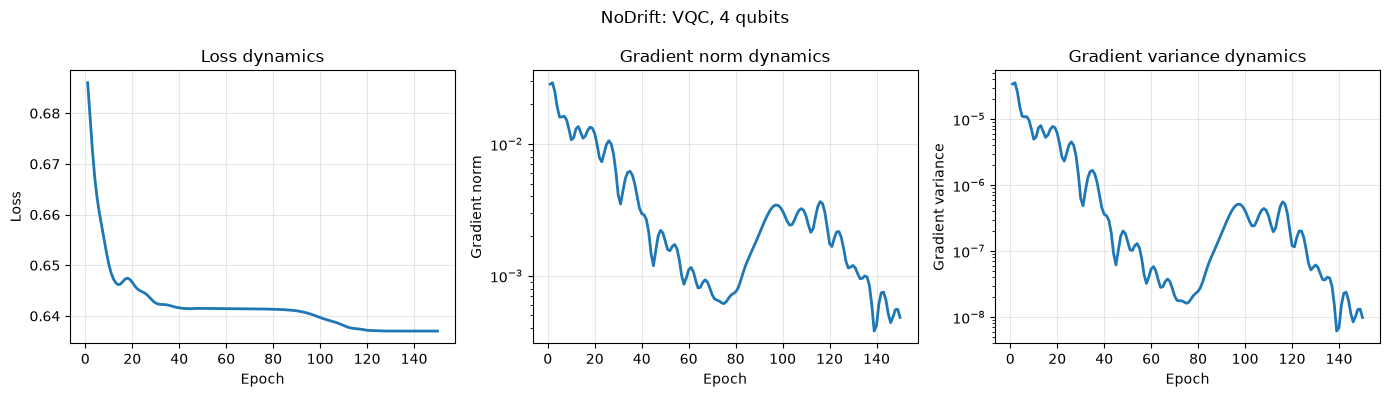


Dataset: NoDrift | Model: VQC | Qubits: 6
Epoch 000 | loss=0.69916 | grad_norm=5.138e-02 | grad_var=7.386e-05
Epoch 050 | loss=0.63773 | grad_norm=4.456e-03 | grad_var=5.419e-07
Epoch 100 | loss=0.63408 | grad_norm=1.697e-03 | grad_var=8.183e-08


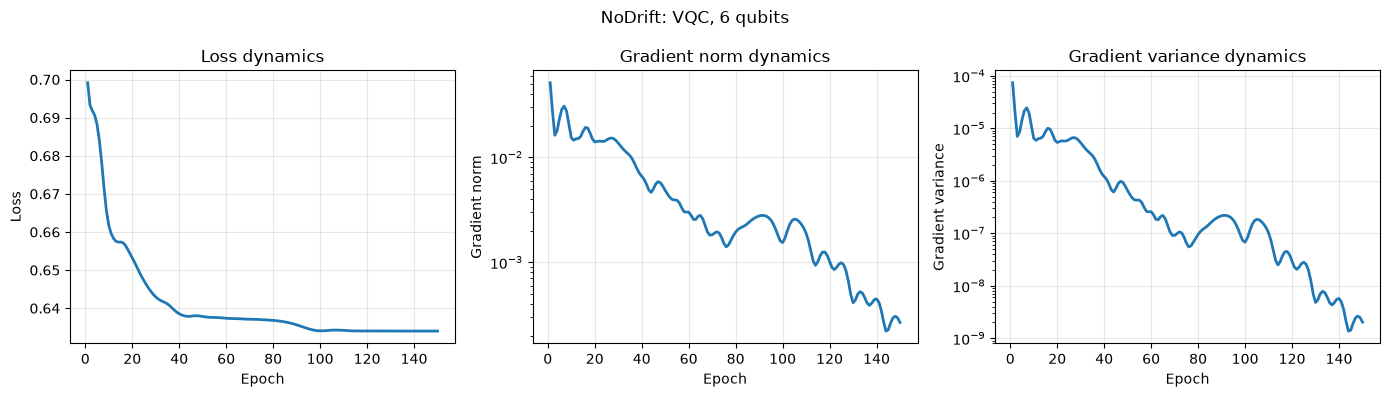


Dataset: NoDrift | Model: VQC | Qubits: 8
Epoch 000 | loss=0.69663 | grad_norm=1.040e-02 | grad_var=2.300e-06
Epoch 050 | loss=0.63765 | grad_norm=5.864e-03 | grad_var=6.867e-07
Epoch 100 | loss=0.63519 | grad_norm=5.540e-04 | grad_var=6.516e-09


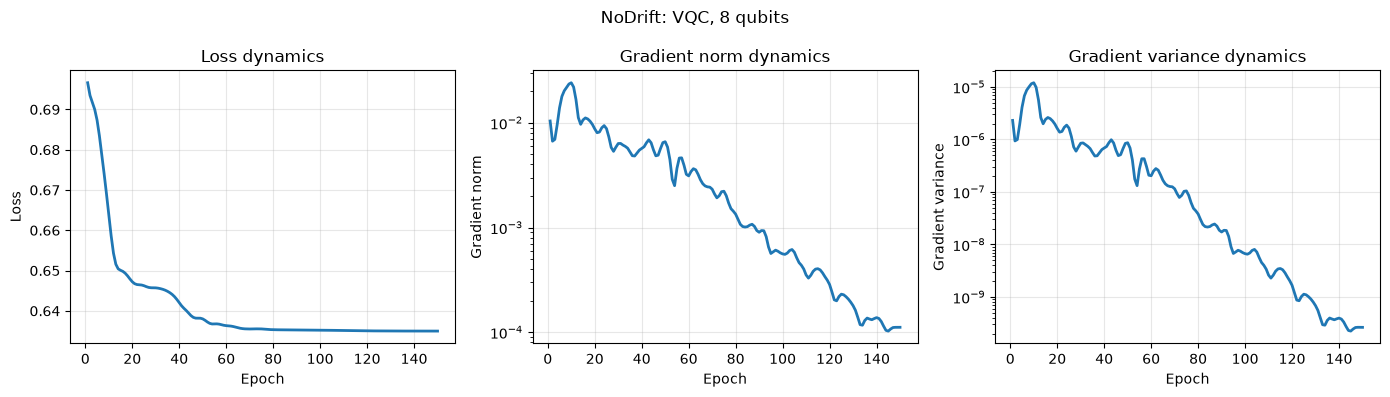


Dataset: NoDrift | Model: VQC | Qubits: 10
Epoch 000 | loss=0.69393 | grad_norm=9.750e-03 | grad_var=1.594e-06
Epoch 050 | loss=0.63371 | grad_norm=5.440e-03 | grad_var=4.745e-07
Epoch 100 | loss=0.63166 | grad_norm=1.475e-03 | grad_var=3.546e-08


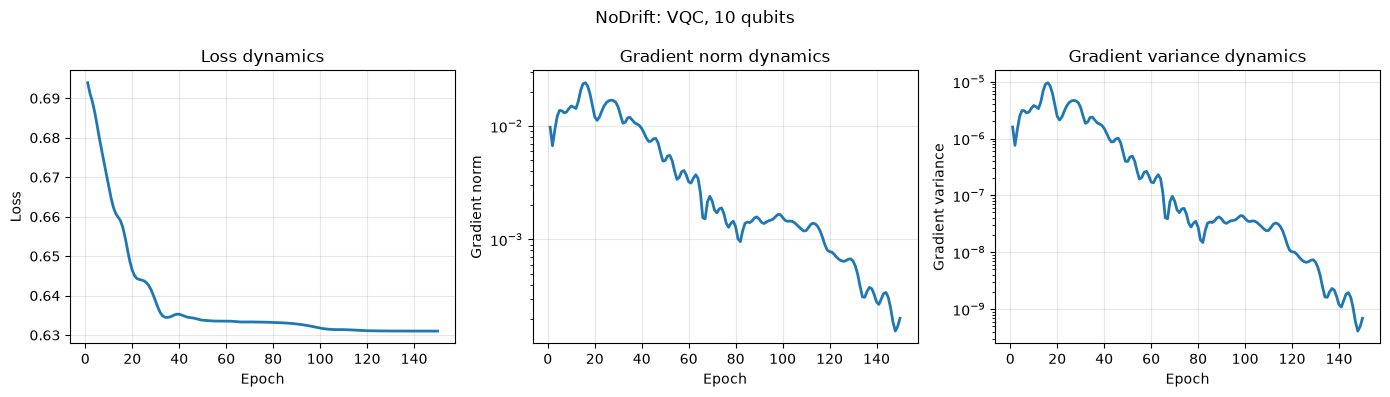


Dataset: WithDrift | Model: VQC | Qubits: 2
Epoch 000 | loss=0.66487 | grad_norm=3.387e-02 | grad_var=9.780e-05
Epoch 050 | loss=0.64696 | grad_norm=1.208e-03 | grad_var=7.773e-08
Epoch 100 | loss=0.64694 | grad_norm=7.905e-05 | grad_var=4.453e-10


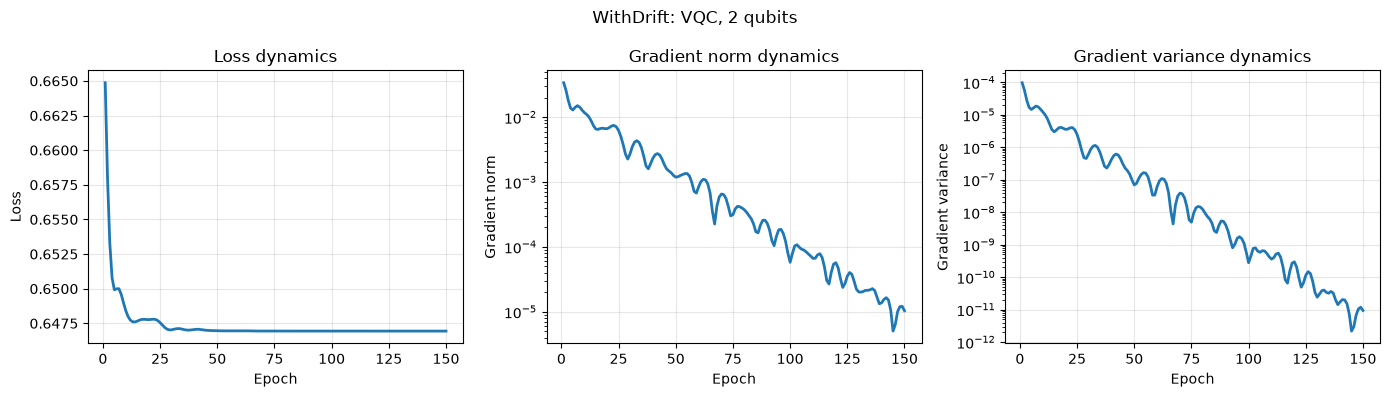


Dataset: WithDrift | Model: VQC | Qubits: 4
Epoch 000 | loss=0.70224 | grad_norm=5.447e-02 | grad_var=1.285e-04
Epoch 050 | loss=0.60503 | grad_norm=9.779e-03 | grad_var=4.153e-06
Epoch 100 | loss=0.60385 | grad_norm=7.220e-04 | grad_var=2.226e-08


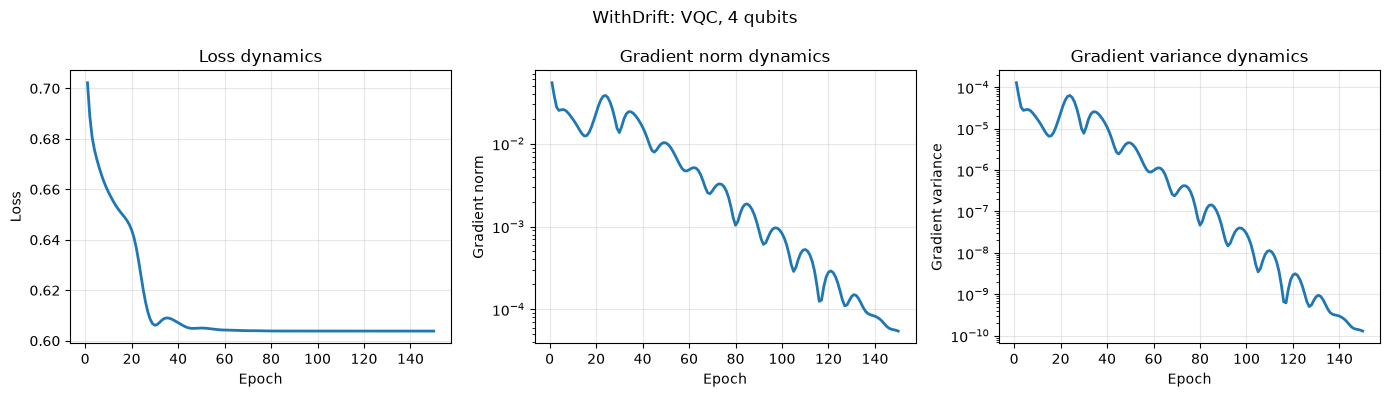


Dataset: WithDrift | Model: VQC | Qubits: 6
Epoch 000 | loss=0.68358 | grad_norm=3.977e-02 | grad_var=4.516e-05
Epoch 050 | loss=0.61066 | grad_norm=6.924e-03 | grad_var=1.336e-06
Epoch 100 | loss=0.60870 | grad_norm=6.238e-04 | grad_var=1.112e-08


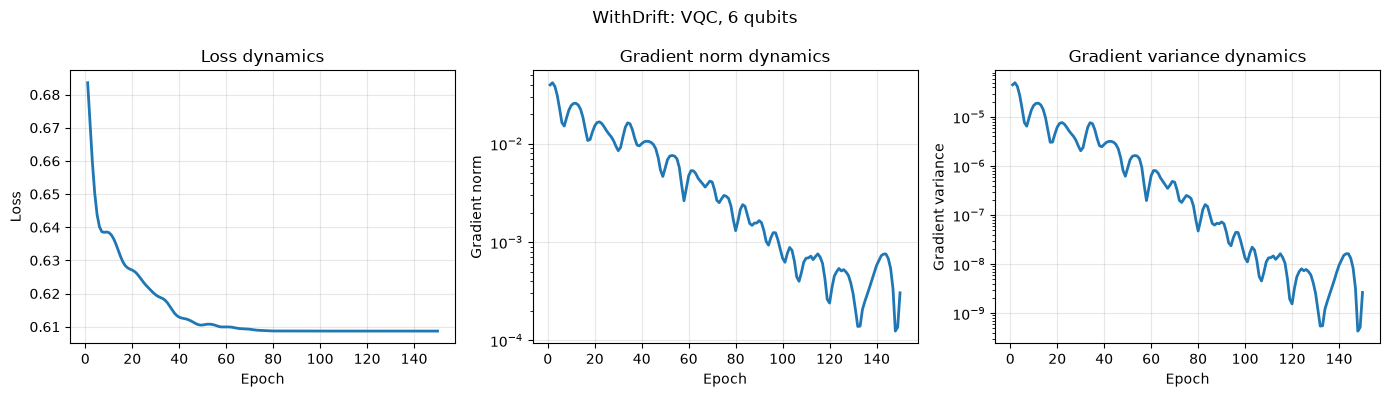


Dataset: WithDrift | Model: VQC | Qubits: 8
Epoch 000 | loss=0.70107 | grad_norm=2.350e-02 | grad_var=1.175e-05
Epoch 050 | loss=0.63946 | grad_norm=7.820e-03 | grad_var=1.192e-06
Epoch 100 | loss=0.62281 | grad_norm=4.604e-03 | grad_var=4.443e-07


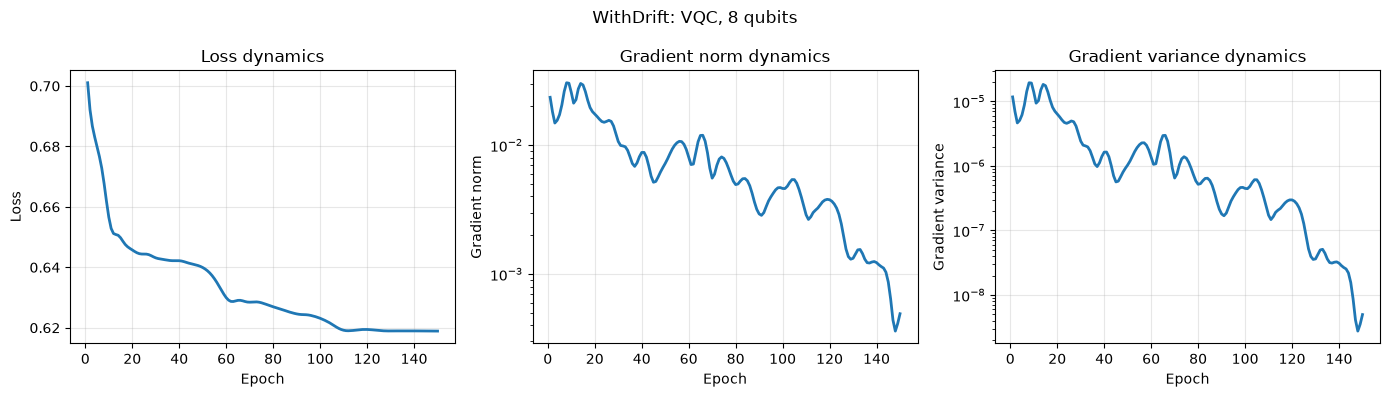


Dataset: WithDrift | Model: VQC | Qubits: 10
Epoch 000 | loss=0.68939 | grad_norm=2.147e-02 | grad_var=7.811e-06
Epoch 050 | loss=0.63746 | grad_norm=4.509e-03 | grad_var=3.426e-07
Epoch 100 | loss=0.62955 | grad_norm=3.766e-03 | grad_var=2.376e-07


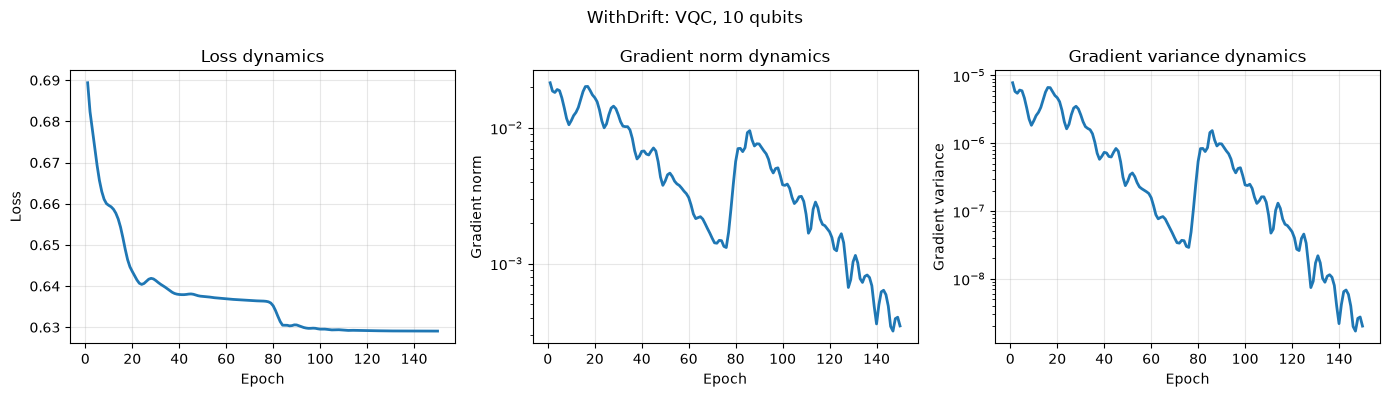

In [25]:
diagnostic_results = []
diagnostic_histories = {}

for dataset_name, X_train, X_test, y_train, y_test in [
    ("NoDrift", X_NoDrift_train, X_NoDrift_test, y_NoDrift_train, y_NoDrift_test),
    ("WithDrift", X_WithDrift_train, X_WithDrift_test, y_WithDrift_train, y_WithDrift_test)
]:
    for q in [2, 4, 6, 8, 10]:
        print(f"\nDataset: {dataset_name} | Model: VQC | Qubits: {q}")

        X_train_q, X_test_q = prepare_quantum_features(X_train, X_test, q)

        model = VQC(n_qubits=q, encoding="angle")

        history = fit_with_gradient_logging(
            model,
            X_train_q,
            y_train,
            epochs=150,
            lr=0.1,
            optimizer_name="adam"
        )

        y_pred = model(torch.tensor(X_test_q, dtype=torch.float32)).detach().numpy()
        y_pred = (y_pred > 0.5).astype(int)

        diagnostic_results.append({
            "Dataset": dataset_name,
            "Model": "VQC_diagnostic",
            "n_qubits": q,
            "Final_Loss": history["loss"][-1],
            "Mean_Last20_Grad_Norm": np.mean(history["grad_norm"][-20:]),
            "Mean_Last20_Grad_Var": np.mean(history["grad_var"][-20:]),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0)
        })

        key = f"{dataset_name}_VQC_{q}"
        diagnostic_histories[key] = history

        plot_barren_plateau_diagnostics(
            history,
            title=f"{dataset_name}: VQC, {q} qubits"
        )

In [26]:
diagnostic_df = pd.DataFrame(diagnostic_results)
diagnostic_df

,Dataset,Model,n_qubits,Final_Loss,Mean_Last20_Grad_Norm,Mean_Last20_Grad_Var,Accuracy,Precision,Recall,F1
0,NoDrift,VQC_diagnostic,2,0.606370,0.000044,1.800308e-10,0.611111,0.581818,0.727273,0.646465
1,NoDrift,VQC_diagnostic,4,0.637022,0.000704,2.299789e-08,0.622222,0.596154,0.704545,0.645833
2,NoDrift,VQC_diagnostic,6,0.634004,0.000371,4.168965e-09,0.544444,0.538462,0.477273,0.506024
3,NoDrift,VQC_diagnostic,8,0.634979,0.000124,3.280064e-10,0.555556,0.534483,0.704545,0.607843
4,NoDrift,VQC_diagnostic,10,0.631009,0.000314,1.766074e-09,0.533333,0.520833,0.568182,0.543478
5,WithDrift,VQC_diagnostic,2,0.646942,0.000015,2.001027e-11,0.577778,0.521739,0.307692,0.387097
6,WithDrift,VQC_diagnostic,4,0.603841,0.000087,3.485887e-10,0.677778,0.777778,0.358974,0.491228
7,WithDrift,VQC_diagnostic,6,0.608684,0.000403,6.001999e-09,0.655556,0.833333,0.256410,0.392157
8,WithDrift,VQC_diagnostic,8,0.618906,0.001056,2.621873e-08,0.722222,0.718750,0.589744,0.647887
9,WithDrift,VQC_diagnostic,10,0.629071,0.000612,7.187609e-09,0.488889,0.422222,0.487179,0.452381


### Gradient Scaling with the Number of Qubits

Следующий график показывает, как средняя норма градиента за последние эпохи меняется при увеличении числа кубитов.

Для Barren Plateaus характерно экспоненциальное уменьшение дисперсии градиента с ростом числа кубитов. В упрощённом виде это можно записать так:

$$
\mathrm{Var}\left[\frac{\partial C(\theta)}{\partial \theta_i}\right] \sim \mathcal{O}\left(\frac{1}{2^n}\right)
$$

где:

- $\mathrm{Var}\left[\frac{\partial C(\theta)}{\partial \theta_i}\right]$ — дисперсия градиента по параметру $\theta_i$;
- $n$ — число кубитов.

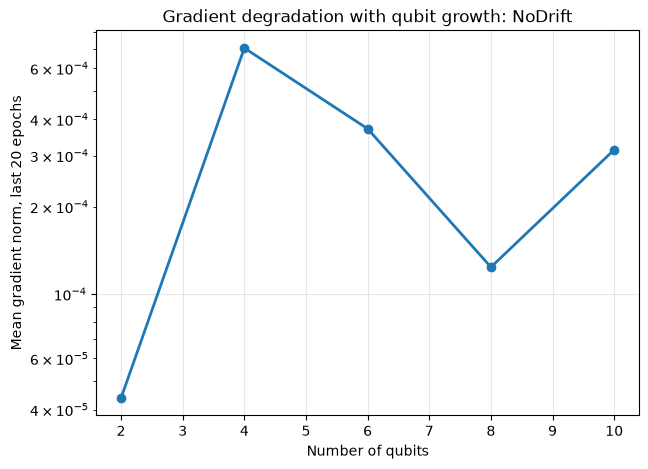

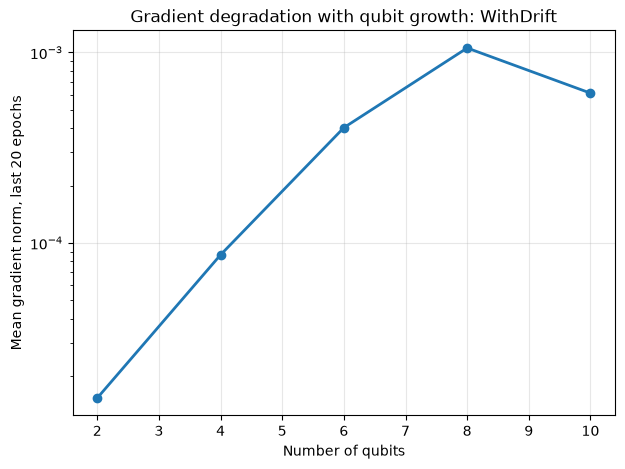

In [27]:
def plot_gradient_vs_qubits(df, dataset_name):
    part = df[df["Dataset"] == dataset_name].sort_values("n_qubits")

    plt.figure(figsize=(7, 5))
    plt.plot(
        part["n_qubits"],
        part["Mean_Last20_Grad_Norm"],
        marker="o",
        linewidth=2
    )
    plt.yscale("log")
    plt.xlabel("Number of qubits")
    plt.ylabel("Mean gradient norm, last 20 epochs")
    plt.title(f"Gradient degradation with qubit growth: {dataset_name}")
    plt.grid(alpha=0.3)
    plt.savefig(f"../graphics/grad_vs_qubits_{dataset_name}.png", dpi=120)
    plt.show()


plot_gradient_vs_qubits(diagnostic_df, "NoDrift")
plot_gradient_vs_qubits(diagnostic_df, "WithDrift")

### Alternative Ansatz Architectures

Исходная модель использует `StronglyEntanglingLayers`. Такой Ansatz является выразительным, но при увеличении числа кубитов и глубины схемы может приводить к слишком сложному ландшафту оптимизации.

Поэтому добавим альтернативные схемы, не изменяя старые классы `VQC` и `VQC_hybrid`. Будут рассмотрены три варианта Ansatz:

1. `strong` — схема на основе `StronglyEntanglingLayers`;
2. `basic` — более простая схема на основе `BasicEntanglerLayers`;
3. `ry_cz` — ручная схема с чередованием `RY` и `CZ`.

По сравнению с прошлой статьёй `VQCAnsatz` также получает параметр `encoding` (`angle` / `iqp`) — это тот же класс, который используется далее и в сравнении кодирований, и в адаптивной пересборке схемы.

In [28]:
class VQCAnsatz(nn.Module):
    def __init__(self, n_qubits=2, n_layers=2, ansatz_type="basic", encoding="angle", dev_name="default.qubit", init_scale=0.01):
        super(VQCAnsatz, self).__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.ansatz_type = ansatz_type
        self.encoding = encoding
        self.dev = qml.device(dev_name, wires=n_qubits)

        def embed(inputs):
            if encoding == "angle":
                qml.AngleEmbedding(inputs, wires=range(n_qubits))
            elif encoding == "iqp":
                qml.IQPEmbedding(inputs, wires=range(n_qubits), n_repeats=2)
            else:
                raise ValueError("encoding must be 'angle' or 'iqp'")

        if ansatz_type == "strong":
            weight_shapes = {"weights": (n_layers, n_qubits, 3)}

            @qml.qnode(self.dev, interface="torch")
            def quantum_circuit(inputs, weights):
                embed(inputs)
                qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
                return qml.expval(qml.PauliZ(0))

        elif ansatz_type == "basic":
            weight_shapes = {"weights": (n_layers, n_qubits)}

            @qml.qnode(self.dev, interface="torch")
            def quantum_circuit(inputs, weights):
                embed(inputs)
                qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
                return qml.expval(qml.PauliZ(0))

        elif ansatz_type == "ry_cz":
            weight_shapes = {"weights": (n_layers, n_qubits)}

            @qml.qnode(self.dev, interface="torch")
            def quantum_circuit(inputs, weights):
                embed(inputs)

                for layer in range(n_layers):
                    for wire in range(n_qubits):
                        qml.RY(weights[layer, wire], wires=wire)

                    for wire in range(n_qubits - 1):
                        qml.CZ(wires=[wire, wire + 1])

                return qml.expval(qml.PauliZ(0))

        else:
            raise ValueError("ansatz_type must be 'strong', 'basic' or 'ry_cz'")

        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        with torch.no_grad():
            for param in self.quantum_layer.parameters():
                param.normal_(mean=0.0, std=init_scale)

        self.model = nn.Sequential(
            self.quantum_layer,
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze()

### Ansatz Comparison

Теперь сравним несколько вариантов квантовой схемы при одинаковом числе кубитов на обоих режимах дрейфа. Это позволит проверить гипотезу: более простые схемы могут обучаться стабильнее, потому что реже попадают в область исчезающих градиентов.

Для бинарной классификации выход модели можно интерпретировать как вероятность принадлежности к положительному классу:

$$
\hat{y} = \sigma(z)
$$

где:

- $\hat{y}$ — предсказанная вероятность класса 1 (`y_high_vol = 1`, повышенная волатильность MOEX на горизонте 5 дней);
- $\sigma$ — сигмоидная функция;
- $z$ — выход квантовой схемы (математическое ожидание оператора Паули $Z$ на первом кубите).

In [29]:
ansatz_results = []
ansatz_histories = {}

for dataset_name, X_train, X_test, y_train, y_test in [
    ("NoDrift", X_NoDrift_train, X_NoDrift_test, y_NoDrift_train, y_NoDrift_test),
    ("WithDrift", X_WithDrift_train, X_WithDrift_test, y_WithDrift_train, y_WithDrift_test)
]:
    for q in [2, 4, 6, 8, 10]:
        X_train_q, X_test_q = prepare_quantum_features(X_train, X_test, q)

        for ansatz_type in ["ry_cz", "basic", "strong"]:
            print(f"\nDataset: {dataset_name} | Ansatz: {ansatz_type} | Qubits: {q}")

            model = VQCAnsatz(
                n_qubits=q,
                n_layers=2,
                ansatz_type=ansatz_type,
                encoding="angle",
                init_scale=0.01
            )

            history = fit_with_gradient_logging(
                model,
                X_train_q,
                y_train,
                epochs=150,
                lr=0.05,
                optimizer_name="adam"
            )

            y_pred = model(torch.tensor(X_test_q, dtype=torch.float32)).detach().numpy()
            y_pred = (y_pred > 0.5).astype(int)

            ansatz_results.append({
                "Dataset": dataset_name,
                "Ansatz": ansatz_type,
                "n_qubits": q,
                "Final_Loss": history["loss"][-1],
                "Mean_Last20_Grad_Norm": np.mean(history["grad_norm"][-20:]),
                "Mean_Last20_Grad_Var": np.mean(history["grad_var"][-20:]),
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1": f1_score(y_test, y_pred, zero_division=0)
            })

            key = f"{dataset_name}_{ansatz_type}_{q}"
            ansatz_histories[key] = history


Dataset: NoDrift | Ansatz: ry_cz | Qubits: 2
Epoch 000 | loss=0.76077 | grad_norm=8.877e-04 | grad_var=1.314e-07
Epoch 050 | loss=0.64544 | grad_norm=7.327e-03 | grad_var=9.005e-06
Epoch 100 | loss=0.64480 | grad_norm=6.736e-04 | grad_var=7.612e-08

Dataset: NoDrift | Ansatz: basic | Qubits: 2
Epoch 000 | loss=0.76109 | grad_norm=8.592e-02 | grad_var=1.860e-03
Epoch 050 | loss=0.63580 | grad_norm=2.131e-02 | grad_var=8.983e-05
Epoch 100 | loss=0.63133 | grad_norm=1.630e-03 | grad_var=6.824e-07

Dataset: NoDrift | Ansatz: strong | Qubits: 2
Epoch 000 | loss=0.78498 | grad_norm=2.729e-03 | grad_var=6.701e-07
Epoch 050 | loss=0.63914 | grad_norm=2.697e-02 | grad_var=6.610e-05
Epoch 100 | loss=0.60645 | grad_norm=3.106e-03 | grad_var=8.613e-07

Dataset: NoDrift | Ansatz: ry_cz | Qubits: 4
Epoch 000 | loss=0.76077 | grad_norm=2.059e-03 | grad_var=4.547e-07
Epoch 050 | loss=0.64544 | grad_norm=7.295e-03 | grad_var=5.709e-06
Epoch 100 | loss=0.64480 | grad_norm=6.684e-04 | grad_var=4.792e-08

In [30]:
ansatz_df = pd.DataFrame(ansatz_results)
ansatz_df

,Dataset,Ansatz,n_qubits,Final_Loss,Mean_Last20_Grad_Norm,Mean_Last20_Grad_Var,Accuracy,Precision,Recall,F1
0,NoDrift,ry_cz,2,0.644795,0.000080,1.104616e-09,0.655556,0.644444,0.659091,0.651685
1,NoDrift,basic,2,0.631316,0.000232,1.997958e-08,0.577778,0.551724,0.727273,0.627451
2,NoDrift,strong,2,0.606370,0.000413,1.594324e-08,0.611111,0.581818,0.727273,0.646465
3,NoDrift,ry_cz,4,0.644795,0.000079,6.999475e-10,0.655556,0.644444,0.659091,0.651685
4,NoDrift,basic,4,0.630410,0.000026,8.585229e-11,0.700000,0.717949,0.636364,0.674699
5,NoDrift,strong,4,0.637008,0.000283,3.919547e-09,0.622222,0.596154,0.704545,0.645833
6,NoDrift,ry_cz,6,0.644795,0.000078,4.862028e-10,0.655556,0.644444,0.659091,0.651685
7,NoDrift,basic,6,0.626189,0.000033,1.033668e-10,0.666667,0.640000,0.727273,0.680851
8,NoDrift,strong,6,0.630993,0.004163,5.214657e-07,0.622222,0.604167,0.659091,0.630435
9,NoDrift,ry_cz,8,0.644795,0.000079,3.763329e-10,0.655556,0.644444,0.659091,0.651685


### Ansatz Gradient Comparison

Если `StronglyEntanglingLayers` демонстрирует более быстрое падение нормы градиента при росте числа кубитов, это подтверждает предположение о том, что слишком выразительный Ansatz может ухудшать обучаемость модели.

В данном эксперименте основной диагностической величиной является средняя норма градиента за последние эпохи:

$$
G_{\text{last}} = \frac{1}{K}\sum_{t=T-K+1}^{T}\|\nabla C_t(\theta)\|_2
$$

где:

- $G_{\text{last}}$ — средняя норма градиента на последних $K$ эпохах;
- $T$ — общее число эпох обучения.

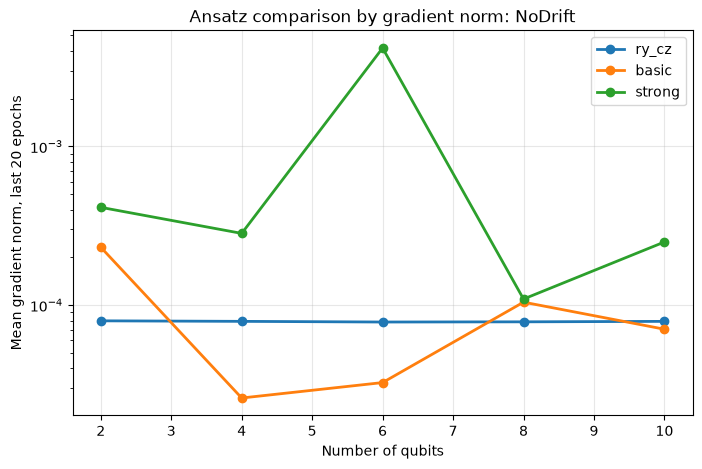

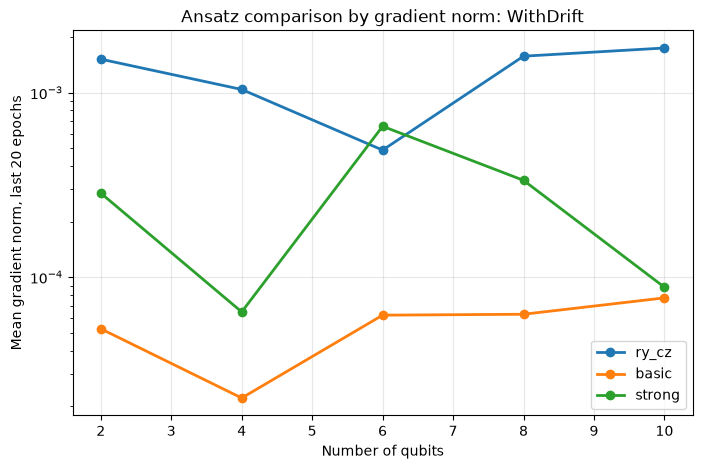

In [31]:
def plot_ansatz_gradient_comparison(df, dataset_name):
    part = df[df["Dataset"] == dataset_name]

    plt.figure(figsize=(8, 5))

    for ansatz_type in part["Ansatz"].unique():
        current = part[part["Ansatz"] == ansatz_type].sort_values("n_qubits")

        plt.plot(
            current["n_qubits"],
            current["Mean_Last20_Grad_Norm"],
            marker="o",
            linewidth=2,
            label=ansatz_type
        )

    plt.yscale("log")
    plt.xlabel("Number of qubits")
    plt.ylabel("Mean gradient norm, last 20 epochs")
    plt.title(f"Ansatz comparison by gradient norm: {dataset_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.savefig(f"../graphics/ansatz_comparison_{dataset_name}.png", dpi=120)
    plt.show()


plot_ansatz_gradient_comparison(ansatz_df, "NoDrift")
plot_ansatz_gradient_comparison(ansatz_df, "WithDrift")

## Encoding Comparison: Angle vs IQP

Это центральный эксперимент научного вклада статьи — сравнение **Angle Encoding** и **IQP Encoding** реальных макроэкономических индикаторов (ключевая ставка ЦБ РФ, инфляция) на обоих режимах Concept Drift. Ansatz зафиксирован (`strong`, `StronglyEntanglingLayers`), меняются только способ кодирования и число кубитов, что позволяет изолировать эффект именно кодирования данных.

Напомним: `IQPEmbedding` требует точного совпадения числа признаков с числом кубитов, поэтому обе схемы здесь используют одинаково подготовленные признаки через `prepare_quantum_features`.

In [32]:
encoding_results = []
encoding_histories = {}

for dataset_name, X_train, X_test, y_train, y_test in [
    ("NoDrift", X_NoDrift_train, X_NoDrift_test, y_NoDrift_train, y_NoDrift_test),
    ("WithDrift", X_WithDrift_train, X_WithDrift_test, y_WithDrift_train, y_WithDrift_test)
]:
    for q in [2, 4, 6, 8, 10]:
        X_train_q, X_test_q = prepare_quantum_features(X_train, X_test, q)

        for encoding in ["angle", "iqp"]:
            print(f"\nDataset: {dataset_name} | Encoding: {encoding} | Qubits: {q}")

            model = VQCAnsatz(
                n_qubits=q,
                n_layers=2,
                ansatz_type="strong",
                encoding=encoding,
                init_scale=0.01
            )

            history = fit_with_gradient_logging(
                model,
                X_train_q,
                y_train,
                epochs=150,
                lr=0.05,
                optimizer_name="adam"
            )

            y_pred = model(torch.tensor(X_test_q, dtype=torch.float32)).detach().numpy()
            y_pred = (y_pred > 0.5).astype(int)

            encoding_results.append({
                "Dataset": dataset_name,
                "Encoding": encoding,
                "n_qubits": q,
                "Final_Loss": history["loss"][-1],
                "Mean_Last20_Grad_Norm": np.mean(history["grad_norm"][-20:]),
                "Mean_Last20_Grad_Var": np.mean(history["grad_var"][-20:]),
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1": f1_score(y_test, y_pred, zero_division=0)
            })

            key = f"{dataset_name}_{encoding}_{q}"
            encoding_histories[key] = history


Dataset: NoDrift | Encoding: angle | Qubits: 2
Epoch 000 | loss=0.78498 | grad_norm=2.731e-03 | grad_var=6.781e-07
Epoch 050 | loss=0.62895 | grad_norm=2.891e-02 | grad_var=6.738e-05
Epoch 100 | loss=0.61441 | grad_norm=2.887e-03 | grad_var=7.287e-07

Dataset: NoDrift | Encoding: iqp | Qubits: 2
Epoch 000 | loss=0.78475 | grad_norm=7.026e-02 | grad_var=4.346e-04
Epoch 050 | loss=0.63839 | grad_norm=1.602e-02 | grad_var=2.083e-05
Epoch 100 | loss=0.62599 | grad_norm=4.683e-03 | grad_var=1.957e-06

Dataset: NoDrift | Encoding: angle | Qubits: 4
Epoch 000 | loss=0.67057 | grad_norm=1.854e-04 | grad_var=1.488e-09
Epoch 050 | loss=0.64179 | grad_norm=3.646e-03 | grad_var=5.258e-07
Epoch 100 | loss=0.63766 | grad_norm=2.229e-03 | grad_var=1.993e-07

Dataset: NoDrift | Encoding: iqp | Qubits: 4
Epoch 000 | loss=0.66961 | grad_norm=3.906e-02 | grad_var=6.608e-05
Epoch 050 | loss=0.63063 | grad_norm=6.460e-03 | grad_var=1.664e-06
Epoch 100 | loss=0.62670 | grad_norm=1.029e-03 | grad_var=4.387e

In [33]:
encoding_df = pd.DataFrame(encoding_results)
encoding_df

,Dataset,Encoding,n_qubits,Final_Loss,Mean_Last20_Grad_Norm,Mean_Last20_Grad_Var,Accuracy,Precision,Recall,F1
0,NoDrift,angle,2,0.606407,0.007179,5.083598e-06,0.611111,0.581818,0.727273,0.646465
1,NoDrift,iqp,2,0.625737,0.000666,4.884208e-08,0.533333,0.525000,0.477273,0.500000
2,NoDrift,angle,4,0.637009,0.000202,1.726878e-09,0.622222,0.596154,0.704545,0.645833
3,NoDrift,iqp,4,0.624924,0.001240,6.963845e-08,0.622222,0.600000,0.681818,0.638298
4,NoDrift,angle,6,0.630588,0.000822,2.010202e-08,0.622222,0.604167,0.659091,0.630435
5,NoDrift,iqp,6,0.643400,0.003710,4.089506e-07,0.688889,0.666667,0.727273,0.695652
6,NoDrift,angle,8,0.637426,0.000344,3.279422e-09,0.533333,0.529412,0.409091,0.461538
7,NoDrift,iqp,8,0.657555,0.000045,4.508864e-11,0.688889,0.648148,0.795455,0.714286
8,NoDrift,angle,10,0.637726,0.000756,9.628449e-09,0.600000,0.576923,0.681818,0.625000
9,NoDrift,iqp,10,0.674073,0.000199,7.073405e-10,0.677778,0.692308,0.613636,0.650602


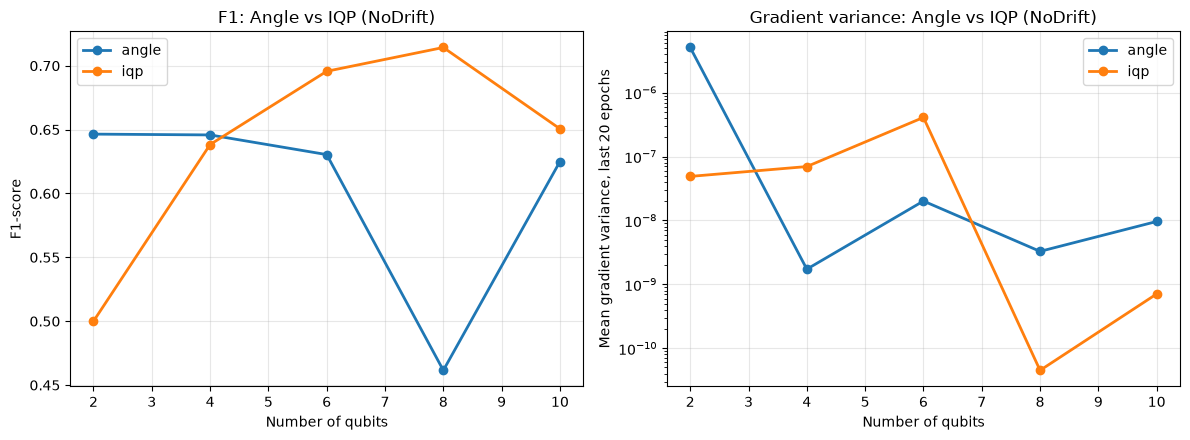

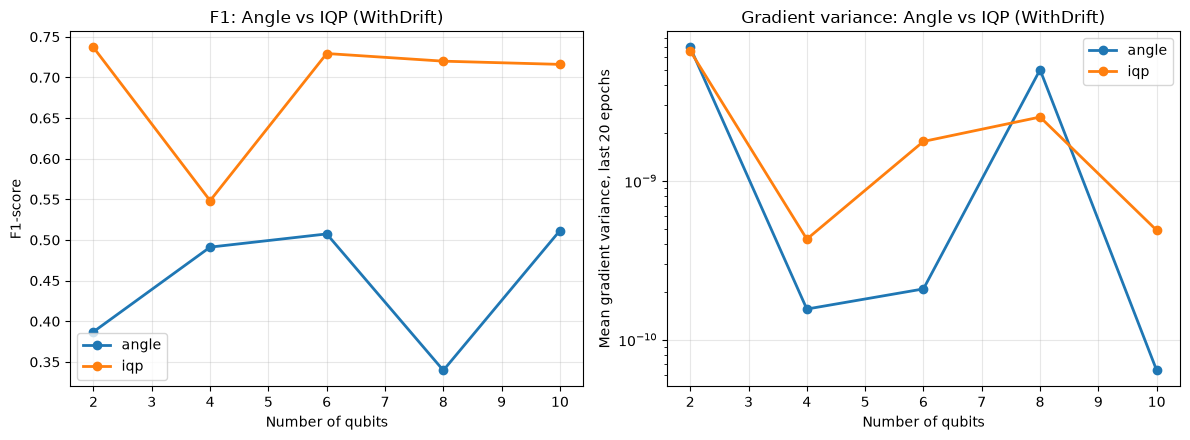

In [34]:
def plot_encoding_comparison(df, dataset_name):
    part = df[df["Dataset"] == dataset_name]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for encoding in part["Encoding"].unique():
        current = part[part["Encoding"] == encoding].sort_values("n_qubits")
        axes[0].plot(current["n_qubits"], current["F1"], marker="o", linewidth=2, label=encoding)
        axes[1].plot(current["n_qubits"], current["Mean_Last20_Grad_Var"], marker="o", linewidth=2, label=encoding)

    axes[0].set_xlabel("Number of qubits"); axes[0].set_ylabel("F1-score")
    axes[0].set_title(f"F1: Angle vs IQP ({dataset_name})")

    axes[1].set_xlabel("Number of qubits"); axes[1].set_ylabel("Mean gradient variance, last 20 epochs")
    axes[1].set_yscale("log")
    axes[1].set_title(f"Gradient variance: Angle vs IQP ({dataset_name})")

    for ax in axes:
        ax.grid(alpha=0.3); ax.legend()

    plt.tight_layout()
    plt.savefig(f"../graphics/encoding_comparison_{dataset_name}.png", dpi=120)
    plt.show()


plot_encoding_comparison(encoding_df, "NoDrift")
plot_encoding_comparison(encoding_df, "WithDrift")

### Does Concept Drift accelerate Barren Plateau?

Сведём результаты `Encoding Comparison` в одну сравнительную таблицу по режимам `NoDrift` / `WithDrift`, чтобы напрямую проверить гипотезу статьи: ускоряет ли Concept Drift наступление Barren Plateau (падение `Mean_Last20_Grad_Var`) при фиксированной схеме и числе кубитов.

In [35]:
drift_effect = encoding_df.pivot_table(
    index=["Encoding", "n_qubits"],
    columns="Dataset",
    values=["F1", "Mean_Last20_Grad_Var"]
)
drift_effect

F1           Mean_Last20_Grad_Var              
Dataset             NoDrift WithDrift              NoDrift     WithDrift
Encoding n_qubits                                                       
angle    2         0.646465  0.387097         5.083598e-06  6.931741e-09
         4         0.645833  0.491228         1.726878e-09  1.558402e-10
         6         0.630435  0.507463         2.010202e-08  2.086817e-10
         8         0.461538  0.339623         3.279422e-09  5.018987e-09
         10        0.625000  0.511628         9.628449e-09  6.403098e-11
iqp      2         0.500000  0.736842         4.884208e-08  6.596985e-09
         4         0.638298  0.548387         6.963845e-08  4.297953e-10
         6         0.695652  0.729412         4.089506e-07  1.773273e-09
         8         0.714286  0.720000         4.508864e-11  2.526345e-09
         10        0.650602  0.716049         7.073405e-10  4.884310e-10

## Dynamic Ansatz Rebuilding

После диагностики можно сформулировать стратегию обхода Barren Plateaus. Вместо того чтобы заранее фиксировать сложную квантовую схему, модель начинает обучение с простой структуры. Далее схема изменяется в зависимости от поведения функции потерь и градиентов.

Для принятия решения используются две величины:

$$
\Delta C = \bar{C}_{prev} - \bar{C}_{curr}
$$

где:

- $\Delta C$ — улучшение функции потерь;
- $\bar{C}_{prev}$ — среднее значение loss на предыдущем окне эпох;
- $\bar{C}_{curr}$ — среднее значение loss на текущем окне эпох.

По сравнению с прошлой статьёй добавлен **drift-aware триггер**: если обучение проходит на участке с высоким уровнем Concept Drift (`drift_flag=True`), при обнаружении `barren_plateau` схема сбрасывается сразу к минимальному Ansatz (`ry_cz`, 1 слой), а не упрощается на один шаг — гипотеза в том, что при сильном дрейфе "мягкое" упрощение недостаточно.

In [36]:
def detect_training_problem(history, loss_window=20, grad_threshold=1e-4, min_loss_improvement=1e-3):
    losses = np.array(history["loss"])
    grad_norms = np.array(history["grad_norm"])

    if len(losses) < loss_window * 2:
        return "not_enough_history"

    previous_loss = losses[-2 * loss_window:-loss_window].mean()
    current_loss = losses[-loss_window:].mean()

    loss_improvement = previous_loss - current_loss
    current_grad_norm = grad_norms[-loss_window:].mean()

    if loss_improvement < min_loss_improvement and current_grad_norm < grad_threshold:
        return "barren_plateau"

    if loss_improvement < min_loss_improvement and current_grad_norm >= grad_threshold:
        return "expressivity_limit"

    return "normal_training"

### Adaptive Ansatz Selection Algorithm

Логика адаптивной стратегии:

1. начать с простой схемы `ry_cz`;
2. обучить модель несколько эпох;
3. определить режим обучения;
4. если возник Barren Plateau — упростить схему (либо принудительно сбросить её к минимальной, если участок отнесён к `WithDrift`);
5. если не хватает выразительности — перейти к более сложной схеме;
6. сохранить историю пересборки.

Функция дополнительно принимает параметры `encoding` (`angle`/`iqp`) и `drift_flag`, чтобы можно было запускать адаптивную стратегию для обоих способов кодирования на обоих режимах дрейфа.

In [37]:
def run_adaptive_ansatz_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name,
    n_qubits,
    encoding="angle",
    drift_flag=False,
    epochs_per_stage=100,
    lr=0.05,
    grad_threshold=1e-4
):
    ansatz_sequence = ["ry_cz", "basic", "strong"]

    current_idx = 0
    current_layers = 1

    adaptive_history = {
        "loss": [],
        "grad_norm": [],
        "grad_var": [],
        "grad_mean_abs": [],
        "grad_max_abs": [],
        "stage": [],
        "ansatz": [],
        "layers": []
    }

    rebuild_log = []

    X_train_q, X_test_q = prepare_quantum_features(X_train, X_test, n_qubits)

    for stage in range(3):
        current_ansatz = ansatz_sequence[current_idx]

        print(
            f"\nStage {stage} | "
            f"Dataset: {dataset_name} | "
            f"Encoding: {encoding} | "
            f"Qubits: {n_qubits} | "
            f"Ansatz: {current_ansatz} | "
            f"Layers: {current_layers}"
        )

        model = VQCAnsatz(
            n_qubits=n_qubits,
            n_layers=current_layers,
            ansatz_type=current_ansatz,
            encoding=encoding,
            init_scale=0.01
        )

        history = fit_with_gradient_logging(
            model,
            X_train_q,
            y_train,
            epochs=epochs_per_stage,
            lr=lr,
            optimizer_name="adam"
        )

        for key in ["loss", "grad_norm", "grad_var", "grad_mean_abs", "grad_max_abs"]:
            adaptive_history[key].extend(history[key])

        adaptive_history["stage"].extend([stage] * len(history["loss"]))
        adaptive_history["ansatz"].extend([current_ansatz] * len(history["loss"]))
        adaptive_history["layers"].extend([current_layers] * len(history["loss"]))

        problem_type = detect_training_problem(
            history,
            grad_threshold=grad_threshold
        )

        if problem_type == "normal_training":
            action = "keep_current_ansatz"
            rebuild_log.append({
                "stage": stage,
                "problem_type": problem_type,
                "action": action,
                "ansatz": current_ansatz,
                "layers": current_layers
            })
            break

        if problem_type == "expressivity_limit":
            if current_idx < len(ansatz_sequence) - 1:
                current_idx += 1
                action = f"switch_to_{ansatz_sequence[current_idx]}"
            else:
                current_layers += 1
                action = f"increase_layers_to_{current_layers}"

        elif problem_type == "barren_plateau":
            if drift_flag:
                current_idx = 0
                current_layers = 1
                action = "drift_triggered_reset_to_ry_cz"
            else:
                current_idx = max(0, current_idx - 1)
                current_layers = 1
                action = f"simplify_to_{ansatz_sequence[current_idx]}"

        else:
            action = "no_action"

        rebuild_log.append({
            "stage": stage,
            "problem_type": problem_type,
            "action": action,
            "ansatz": current_ansatz,
            "layers": current_layers
        })

        print(f"Detected problem: {problem_type}")
        print(f"Action: {action}")

    y_pred = model(torch.tensor(X_test_q, dtype=torch.float32)).detach().numpy()
    y_pred = (y_pred > 0.5).astype(int)

    final_result = {
        "Dataset": dataset_name,
        "Model": "AdaptiveAnsatzVQC",
        "Encoding": encoding,
        "n_qubits": n_qubits,
        "Final_Ansatz": current_ansatz,
        "Final_Layers": current_layers,
        "Final_Loss": adaptive_history["loss"][-1],
        "Mean_Last20_Grad_Norm": np.mean(adaptive_history["grad_norm"][-20:]),
        "Mean_Last20_Grad_Var": np.mean(adaptive_history["grad_var"][-20:]),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    }

    return final_result, adaptive_history, rebuild_log

### Adaptive Rebuilding Experiment

Теперь запустим адаптивную стратегию для обоих режимов дрейфа, обоих способов кодирования и разного числа кубитов. Цель эксперимента — проверить, позволяет ли динамическая пересборка схемы (в том числе drift-aware триггер) удерживать градиенты от слишком быстрого исчезновения именно на участках с высоким Concept Drift.


Stage 0 | Dataset: NoDrift | Encoding: angle | Qubits: 2 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.76077 | grad_norm=7.995e-04 | grad_var=3.196e-07
Epoch 050 | loss=0.69002 | grad_norm=1.159e-02 | grad_var=6.716e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: angle | Qubits: 2 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.76033 | grad_norm=8.543e-02 | grad_var=3.649e-03
Epoch 050 | loss=0.63153 | grad_norm=7.940e-03 | grad_var=3.152e-05
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: angle | Qubits: 2 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.66000 | grad_norm=3.460e-04 | grad_var=2.133e-08
Epoch 050 | loss=0.65392 | grad_norm=1.079e-03 | grad_var=2.190e-07
Detected problem: expressivity_limit
Action: increase_layers_to_2


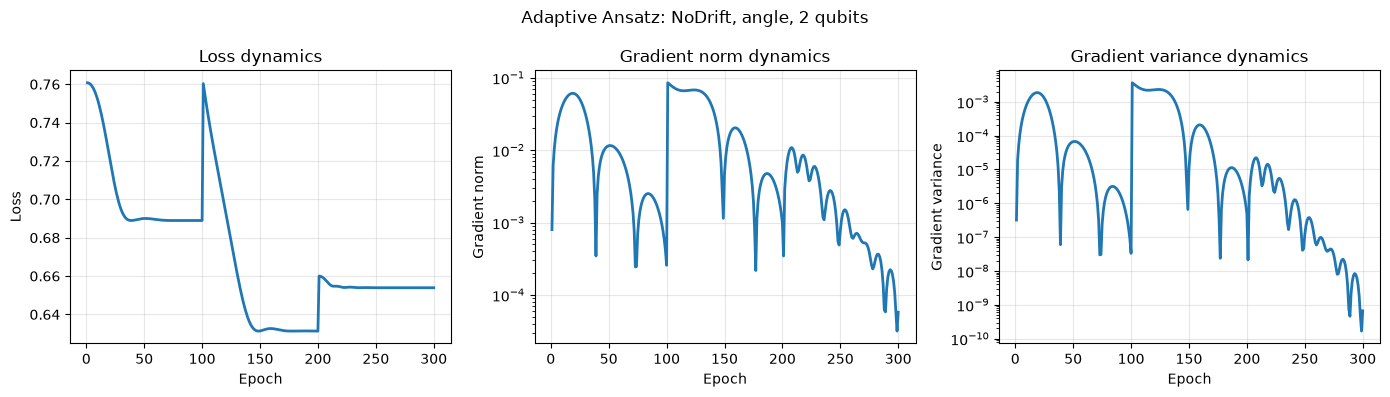


Stage 0 | Dataset: NoDrift | Encoding: iqp | Qubits: 2 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.75720 | grad_norm=5.182e-02 | grad_var=1.343e-03
Epoch 050 | loss=0.66283 | grad_norm=1.029e-02 | grad_var=5.296e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: iqp | Qubits: 2 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.75696 | grad_norm=1.737e-02 | grad_var=1.509e-04
Epoch 050 | loss=0.68023 | grad_norm=9.207e-03 | grad_var=4.239e-05
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: iqp | Qubits: 2 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.69963 | grad_norm=6.680e-02 | grad_var=7.436e-04
Epoch 050 | loss=0.64026 | grad_norm=6.606e-03 | grad_var=6.668e-06
Detected problem: expressivity_limit
Action: increase_layers_to_2


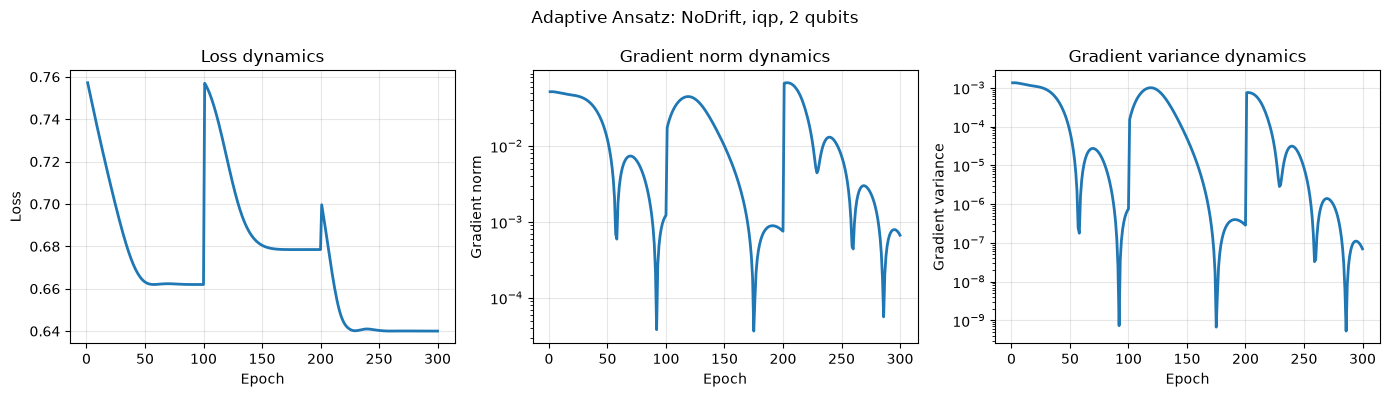


Stage 0 | Dataset: NoDrift | Encoding: angle | Qubits: 4 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.76077 | grad_norm=7.604e-04 | grad_var=1.445e-07
Epoch 050 | loss=0.69002 | grad_norm=1.159e-02 | grad_var=3.359e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: angle | Qubits: 4 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.68565 | grad_norm=3.479e-02 | grad_var=2.206e-04
Epoch 050 | loss=0.66535 | grad_norm=3.124e-03 | grad_var=1.745e-06
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: angle | Qubits: 4 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.68524 | grad_norm=5.440e-04 | grad_var=2.626e-08
Epoch 050 | loss=0.66539 | grad_norm=8.517e-04 | grad_var=5.680e-08
Detected problem: expressivity_limit
Action: increase_layers_to_2


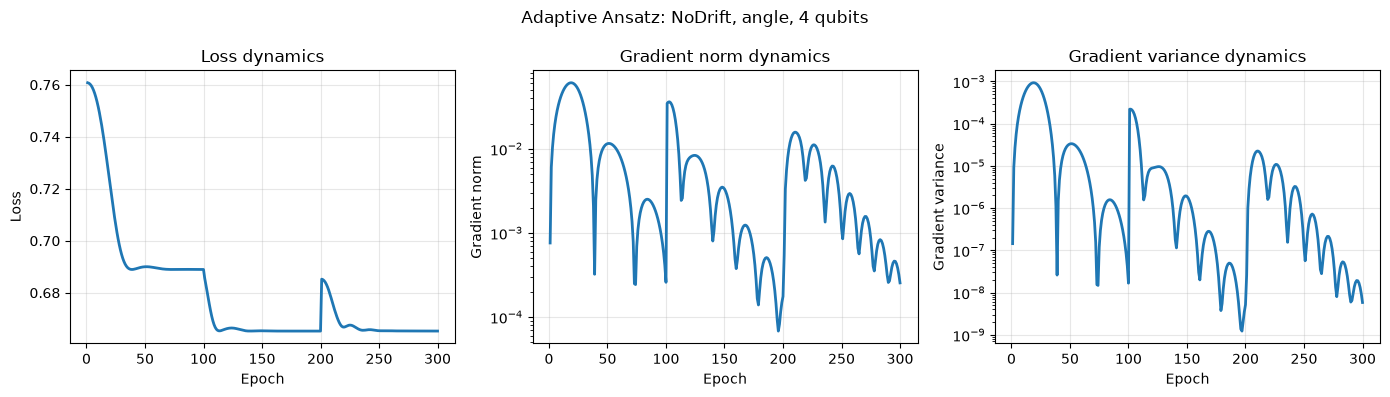


Stage 0 | Dataset: NoDrift | Encoding: iqp | Qubits: 4 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.69226 | grad_norm=1.935e-02 | grad_var=9.361e-05
Epoch 050 | loss=0.67951 | grad_norm=1.857e-03 | grad_var=8.619e-07
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: iqp | Qubits: 4 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.70422 | grad_norm=2.508e-02 | grad_var=1.318e-04
Epoch 050 | loss=0.67243 | grad_norm=4.112e-03 | grad_var=2.182e-06
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: iqp | Qubits: 4 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.70434 | grad_norm=1.412e-02 | grad_var=1.492e-05
Epoch 050 | loss=0.65504 | grad_norm=5.775e-03 | grad_var=2.284e-06
Detected problem: expressivity_limit
Action: increase_layers_to_2


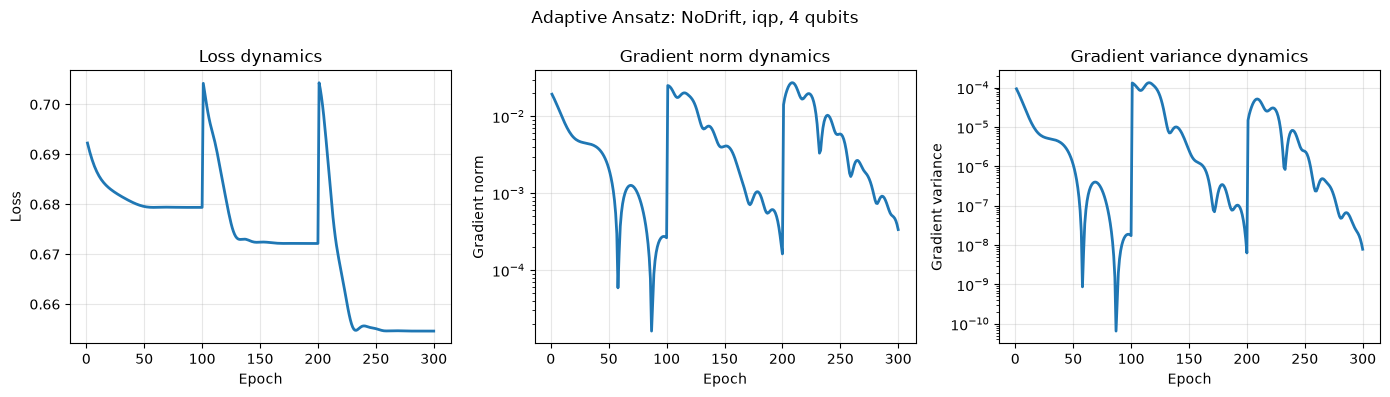


Stage 0 | Dataset: NoDrift | Encoding: angle | Qubits: 6 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.76078 | grad_norm=6.789e-05 | grad_var=7.681e-10
Epoch 050 | loss=0.69003 | grad_norm=1.163e-02 | grad_var=2.256e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: angle | Qubits: 6 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.67215 | grad_norm=1.537e-02 | grad_var=4.102e-05
Epoch 050 | loss=0.64332 | grad_norm=1.559e-03 | grad_var=4.619e-07
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: angle | Qubits: 6 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.67230 | grad_norm=2.689e-04 | grad_var=4.167e-09
Epoch 050 | loss=0.64580 | grad_norm=1.072e-02 | grad_var=6.675e-06
Detected problem: expressivity_limit
Action: increase_layers_to_2


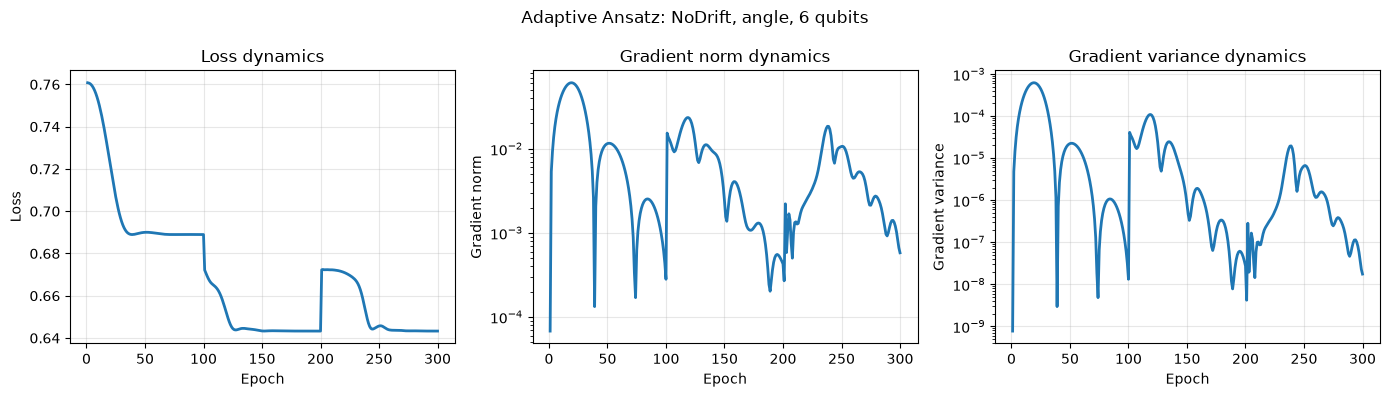


Stage 0 | Dataset: NoDrift | Encoding: iqp | Qubits: 6 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.69255 | grad_norm=1.440e-02 | grad_var=3.457e-05
Epoch 050 | loss=0.68155 | grad_norm=1.175e-03 | grad_var=2.301e-07
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: iqp | Qubits: 6 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.68870 | grad_norm=1.478e-02 | grad_var=3.014e-05
Epoch 050 | loss=0.67556 | grad_norm=1.381e-03 | grad_var=3.724e-07
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: iqp | Qubits: 6 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.68875 | grad_norm=2.017e-02 | grad_var=2.382e-05
Epoch 050 | loss=0.66776 | grad_norm=1.643e-03 | grad_var=1.542e-07


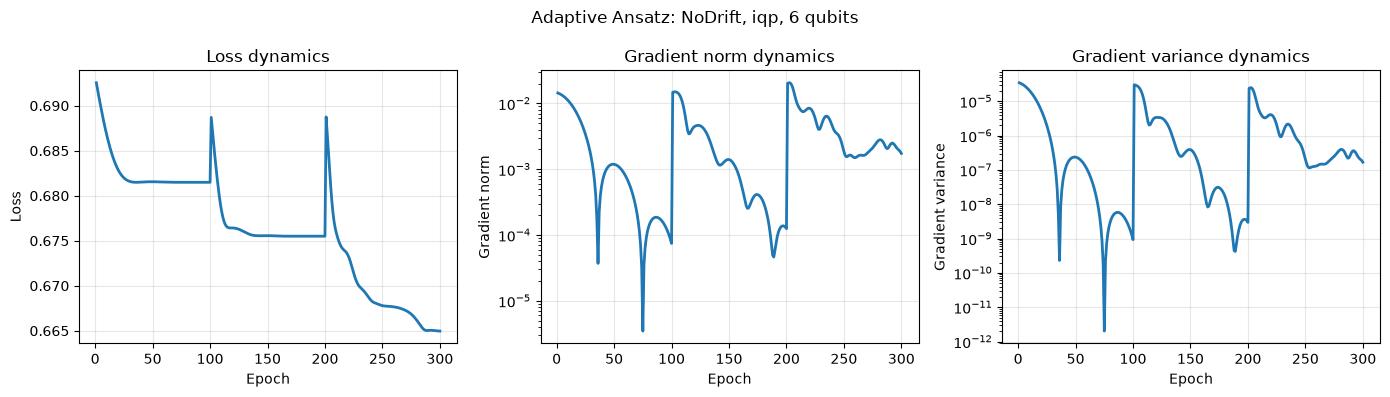


Stage 0 | Dataset: NoDrift | Encoding: angle | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.76078 | grad_norm=1.642e-05 | grad_var=3.371e-11
Epoch 050 | loss=0.69003 | grad_norm=1.164e-02 | grad_var=1.693e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: angle | Qubits: 8 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.67030 | grad_norm=1.993e-02 | grad_var=5.292e-05
Epoch 050 | loss=0.65887 | grad_norm=9.916e-04 | grad_var=1.206e-07
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: angle | Qubits: 8 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.67030 | grad_norm=6.190e-04 | grad_var=1.576e-08
Epoch 050 | loss=0.65920 | grad_norm=2.047e-03 | grad_var=1.764e-07
Detected problem: expressivity_limit
Action: increase_layers_to_2


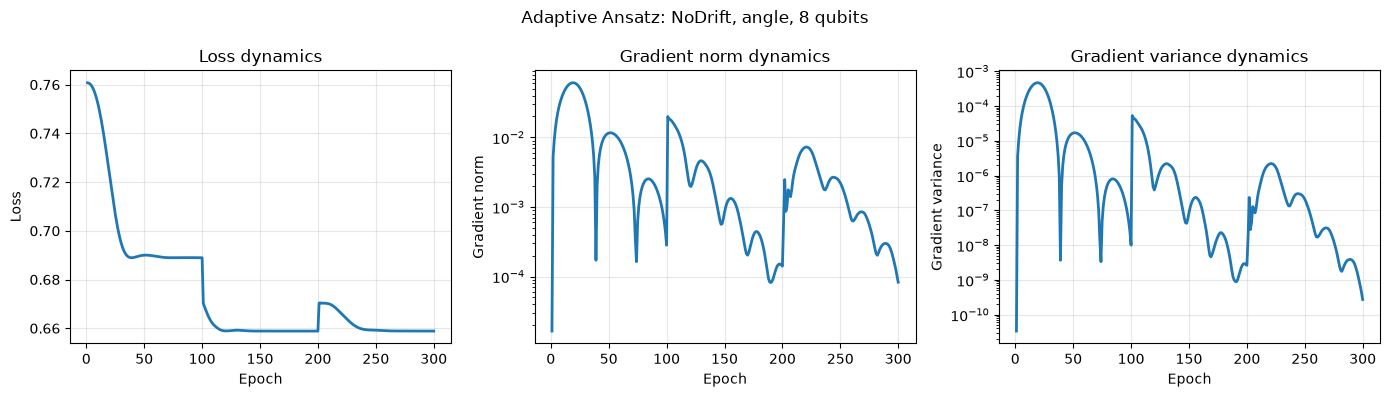


Stage 0 | Dataset: NoDrift | Encoding: iqp | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.69327 | grad_norm=7.010e-03 | grad_var=6.142e-06
Epoch 050 | loss=0.68686 | grad_norm=5.644e-04 | grad_var=3.982e-08
Detected problem: barren_plateau
Action: simplify_to_ry_cz

Stage 1 | Dataset: NoDrift | Encoding: iqp | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.69327 | grad_norm=7.009e-03 | grad_var=6.141e-06
Epoch 050 | loss=0.68686 | grad_norm=5.647e-04 | grad_var=3.986e-08
Detected problem: barren_plateau
Action: simplify_to_ry_cz

Stage 2 | Dataset: NoDrift | Encoding: iqp | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.69321 | grad_norm=6.996e-03 | grad_var=6.118e-06
Epoch 050 | loss=0.68686 | grad_norm=5.716e-04 | grad_var=4.084e-08
Detected problem: barren_plateau
Action: simplify_to_ry_cz


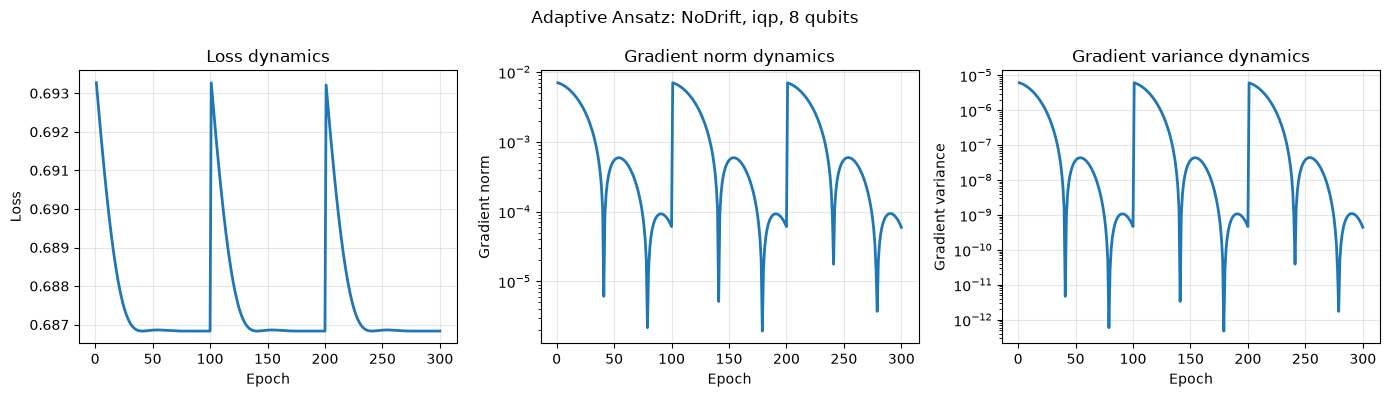


Stage 0 | Dataset: NoDrift | Encoding: angle | Qubits: 10 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.76078 | grad_norm=3.256e-04 | grad_var=1.060e-08
Epoch 050 | loss=0.69003 | grad_norm=1.162e-02 | grad_var=1.350e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: NoDrift | Encoding: angle | Qubits: 10 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.69235 | grad_norm=2.148e-02 | grad_var=3.972e-05
Epoch 050 | loss=0.66454 | grad_norm=2.179e-03 | grad_var=3.371e-07
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: NoDrift | Encoding: angle | Qubits: 10 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.69208 | grad_norm=5.662e-04 | grad_var=1.096e-08
Epoch 050 | loss=0.66475 | grad_norm=2.408e-03 | grad_var=1.943e-07
Detected problem: expressivity_limit
Action: increase_layers_to_2


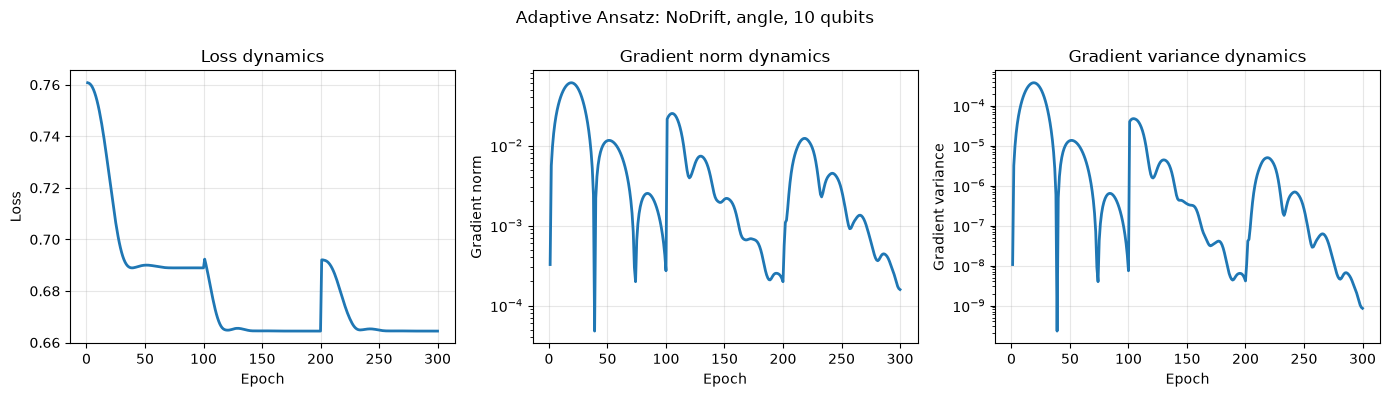


Stage 0 | Dataset: NoDrift | Encoding: iqp | Qubits: 10 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.69350 | grad_norm=2.627e-03 | grad_var=6.902e-07
Epoch 050 | loss=0.69081 | grad_norm=1.990e-04 | grad_var=3.959e-09
Detected problem: barren_plateau
Action: simplify_to_ry_cz

Stage 1 | Dataset: NoDrift | Encoding: iqp | Qubits: 10 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.69349 | grad_norm=2.627e-03 | grad_var=6.902e-07
Epoch 050 | loss=0.69081 | grad_norm=1.993e-04 | grad_var=3.971e-09
Detected problem: barren_plateau
Action: simplify_to_ry_cz

Stage 2 | Dataset: NoDrift | Encoding: iqp | Qubits: 10 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.69354 | grad_norm=2.628e-03 | grad_var=6.904e-07
Epoch 050 | loss=0.69081 | grad_norm=1.922e-04 | grad_var=3.693e-09
Detected problem: barren_plateau
Action: simplify_to_ry_cz


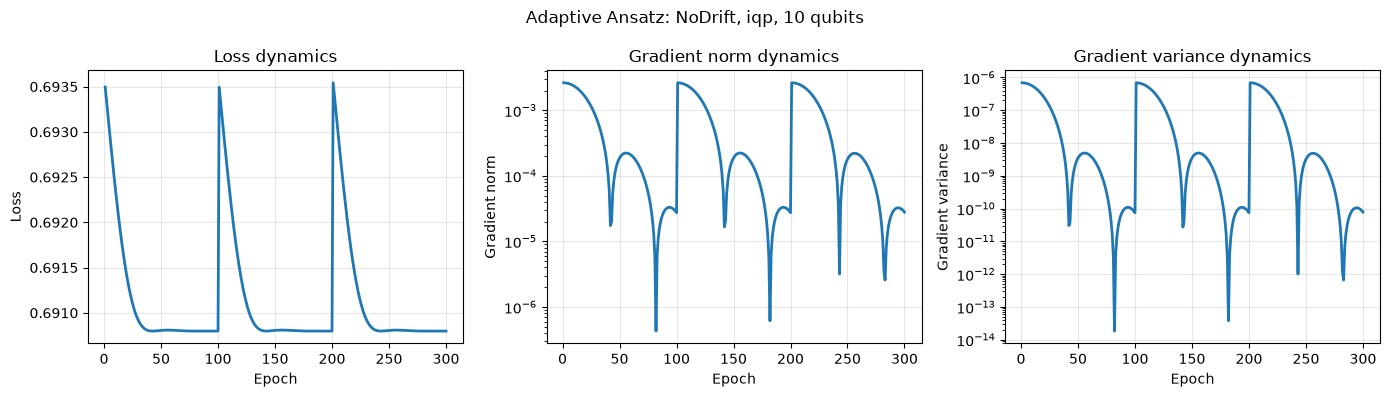


Stage 0 | Dataset: WithDrift | Encoding: angle | Qubits: 2 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.73689 | grad_norm=1.341e-03 | grad_var=8.988e-07
Epoch 050 | loss=0.69308 | grad_norm=5.187e-03 | grad_var=1.345e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: angle | Qubits: 2 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.73478 | grad_norm=1.016e-01 | grad_var=5.162e-03
Epoch 050 | loss=0.69123 | grad_norm=7.503e-03 | grad_var=2.815e-05
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: WithDrift | Encoding: angle | Qubits: 2 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.74488 | grad_norm=1.620e-03 | grad_var=4.605e-07
Epoch 050 | loss=0.61448 | grad_norm=1.359e-02 | grad_var=3.361e-05
Detected problem: expressivity_limit
Action: increase_layers_to_2


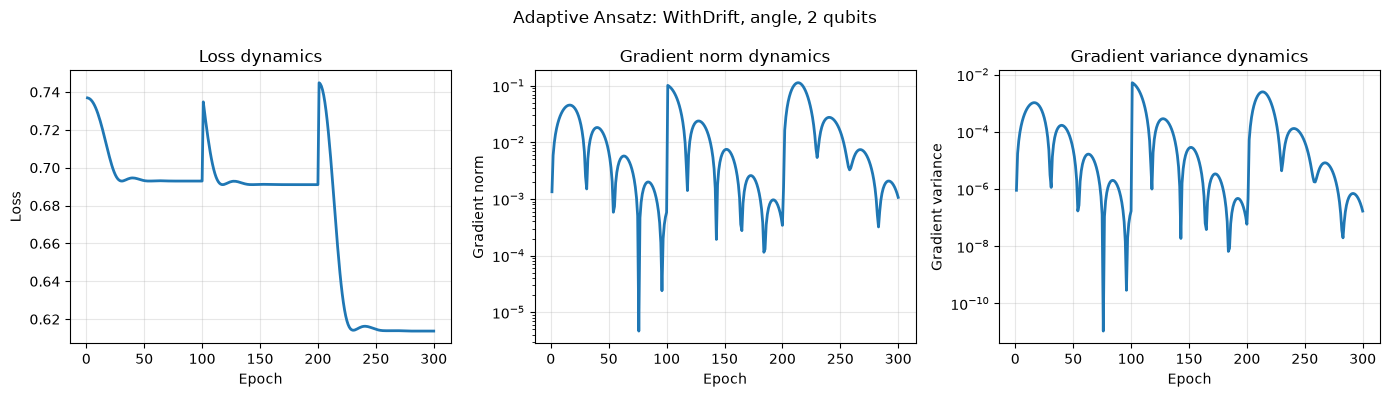


Stage 0 | Dataset: WithDrift | Encoding: iqp | Qubits: 2 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.75232 | grad_norm=2.875e-02 | grad_var=4.133e-04
Epoch 050 | loss=0.66756 | grad_norm=6.318e-03 | grad_var=1.996e-05
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: iqp | Qubits: 2 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.75207 | grad_norm=4.438e-02 | grad_var=9.848e-04
Epoch 050 | loss=0.66175 | grad_norm=5.479e-03 | grad_var=1.501e-05
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: WithDrift | Encoding: iqp | Qubits: 2 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.65181 | grad_norm=4.786e-02 | grad_var=3.819e-04
Epoch 050 | loss=0.63522 | grad_norm=1.619e-03 | grad_var=4.294e-07
Detected problem: expressivity_limit
Action: increase_layers_to_2


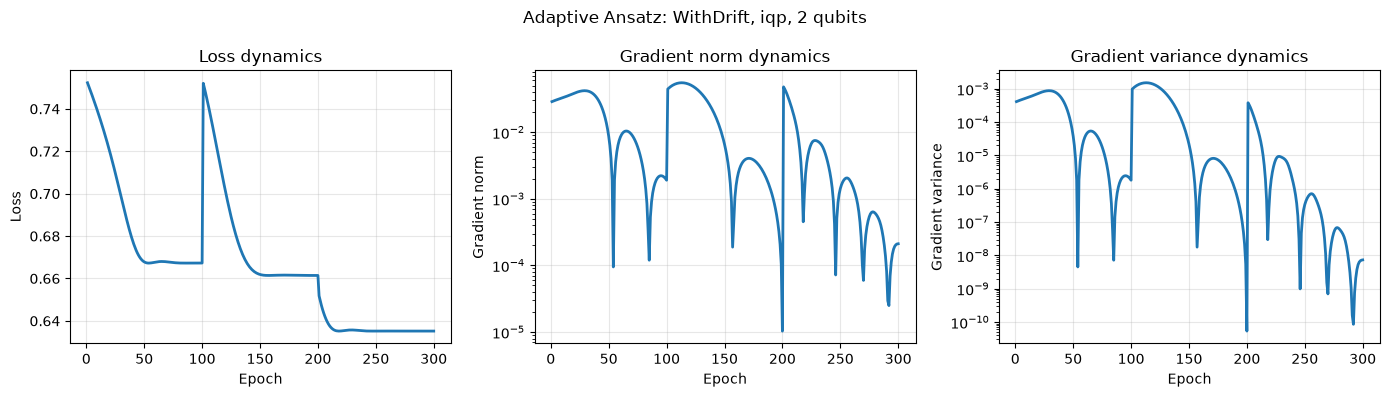


Stage 0 | Dataset: WithDrift | Encoding: angle | Qubits: 4 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.73690 | grad_norm=1.240e-04 | grad_var=3.843e-09
Epoch 050 | loss=0.69312 | grad_norm=5.856e-03 | grad_var=8.574e-06
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: angle | Qubits: 4 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.68024 | grad_norm=6.626e-02 | grad_var=1.448e-03
Epoch 050 | loss=0.66023 | grad_norm=1.207e-02 | grad_var=2.678e-05


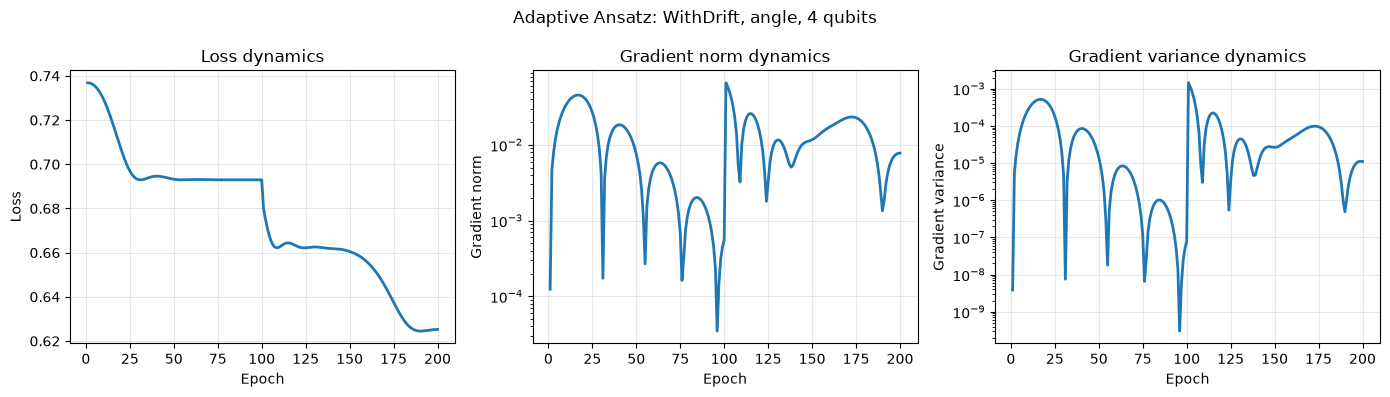


Stage 0 | Dataset: WithDrift | Encoding: iqp | Qubits: 4 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.67887 | grad_norm=2.957e-02 | grad_var=2.186e-04
Epoch 050 | loss=0.66462 | grad_norm=1.414e-03 | grad_var=4.997e-07
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: iqp | Qubits: 4 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.70385 | grad_norm=3.277e-02 | grad_var=2.698e-04
Epoch 050 | loss=0.67090 | grad_norm=1.535e-03 | grad_var=2.917e-07
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: WithDrift | Encoding: iqp | Qubits: 4 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.70383 | grad_norm=2.946e-02 | grad_var=7.154e-05
Epoch 050 | loss=0.66533 | grad_norm=3.474e-03 | grad_var=7.703e-07
Detected problem: expressivity_limit
Action: increase_layers_to_2


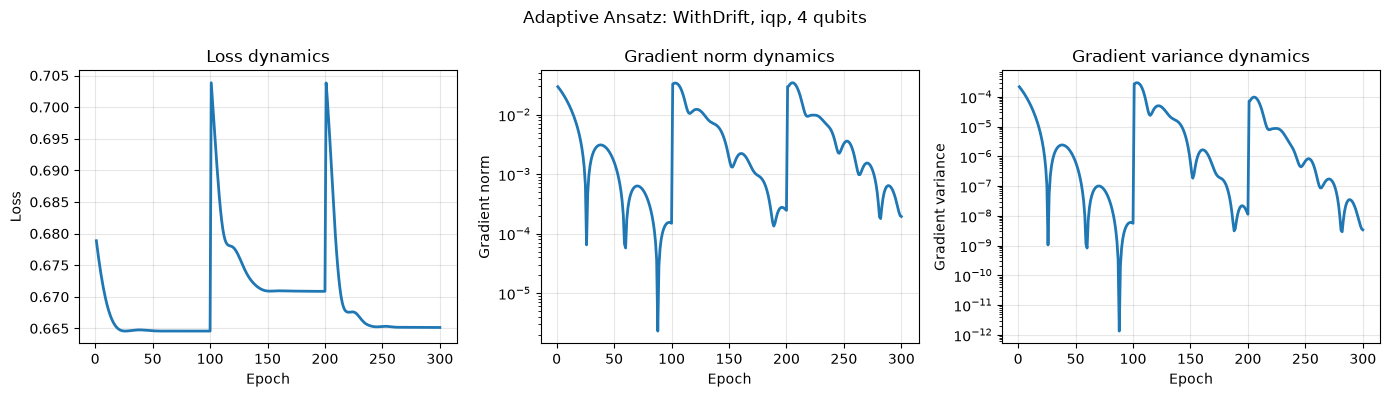


Stage 0 | Dataset: WithDrift | Encoding: angle | Qubits: 6 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.73690 | grad_norm=1.910e-04 | grad_var=6.079e-09
Epoch 050 | loss=0.69312 | grad_norm=5.813e-03 | grad_var=5.632e-06
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: angle | Qubits: 6 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.70902 | grad_norm=4.311e-02 | grad_var=2.174e-04
Epoch 050 | loss=0.63693 | grad_norm=8.633e-03 | grad_var=6.321e-06
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: WithDrift | Encoding: angle | Qubits: 6 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.70854 | grad_norm=6.929e-04 | grad_var=2.197e-08
Epoch 050 | loss=0.63886 | grad_norm=1.546e-02 | grad_var=1.269e-05
Detected problem: expressivity_limit
Action: increase_layers_to_2


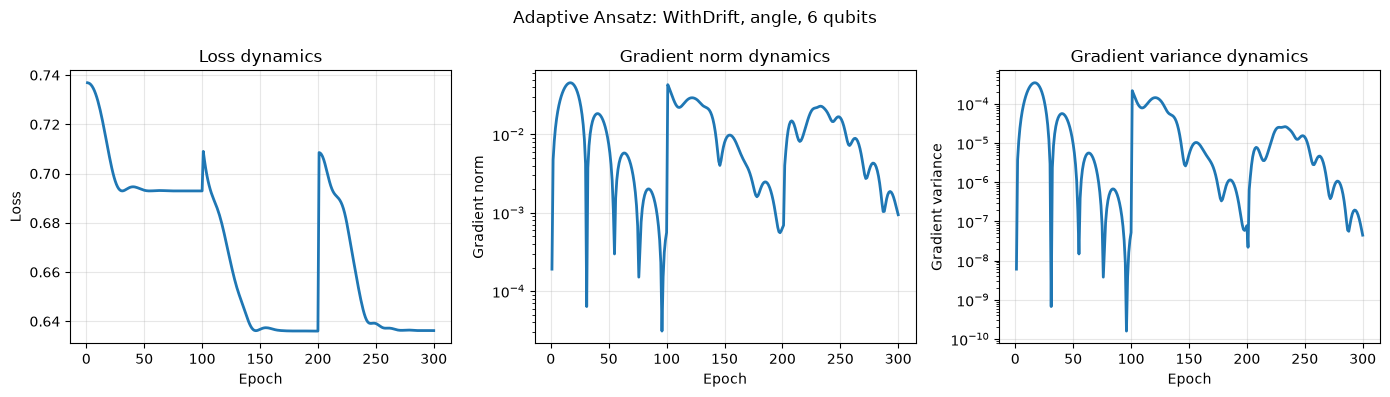


Stage 0 | Dataset: WithDrift | Encoding: iqp | Qubits: 6 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.71493 | grad_norm=1.351e-02 | grad_var=3.043e-05
Epoch 050 | loss=0.67680 | grad_norm=2.586e-03 | grad_var=1.115e-06
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: iqp | Qubits: 6 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.73649 | grad_norm=1.171e-02 | grad_var=1.978e-05
Epoch 050 | loss=0.66810 | grad_norm=5.004e-03 | grad_var=4.616e-06
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: WithDrift | Encoding: iqp | Qubits: 6 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.73655 | grad_norm=1.121e-02 | grad_var=7.083e-06
Epoch 050 | loss=0.65546 | grad_norm=5.064e-03 | grad_var=1.502e-06
Detected problem: expressivity_limit
Action: increase_layers_to_2


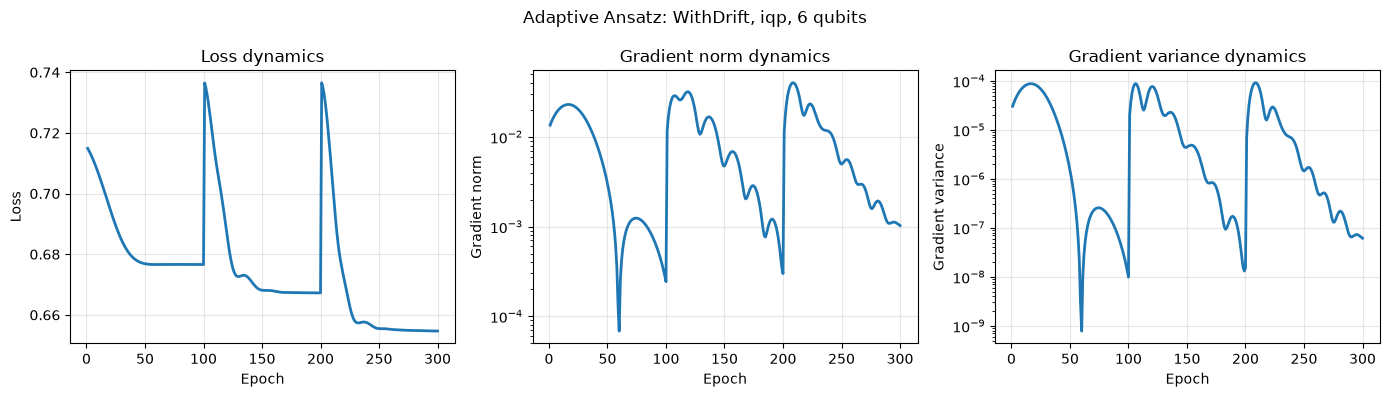


Stage 0 | Dataset: WithDrift | Encoding: angle | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.73689 | grad_norm=9.906e-04 | grad_var=1.227e-07
Epoch 050 | loss=0.69309 | grad_norm=5.360e-03 | grad_var=3.591e-06
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: angle | Qubits: 8 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.69633 | grad_norm=2.120e-02 | grad_var=3.441e-05
Epoch 050 | loss=0.65148 | grad_norm=5.792e-03 | grad_var=4.426e-06
Detected problem: expressivity_limit
Action: switch_to_strong

Stage 2 | Dataset: WithDrift | Encoding: angle | Qubits: 8 | Ansatz: strong | Layers: 1
Epoch 000 | loss=0.69587 | grad_norm=2.816e-04 | grad_var=2.343e-09
Epoch 050 | loss=0.65270 | grad_norm=1.082e-02 | grad_var=4.861e-06
Detected problem: expressivity_limit
Action: increase_layers_to_2


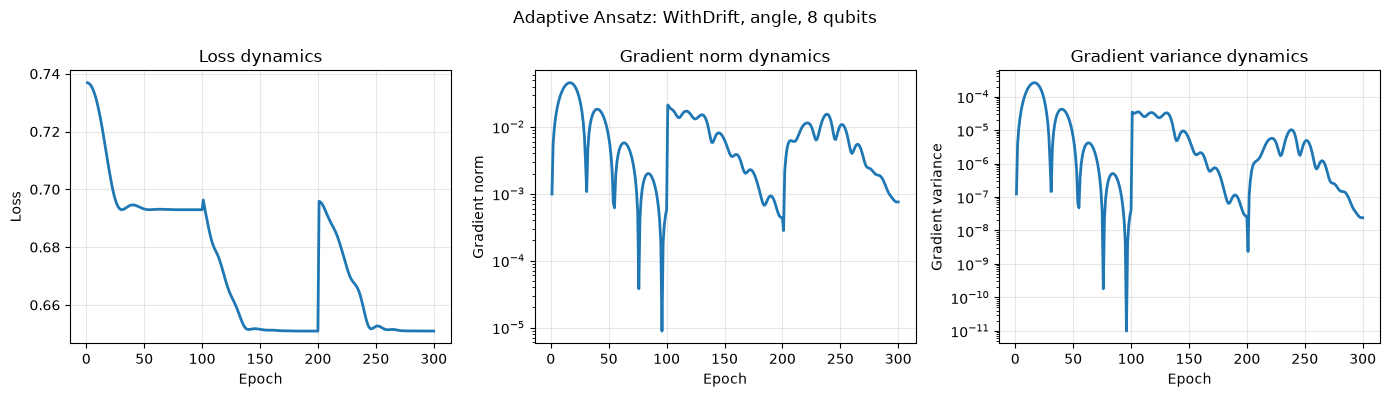


Stage 0 | Dataset: WithDrift | Encoding: iqp | Qubits: 8 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.69818 | grad_norm=7.696e-03 | grad_var=7.404e-06
Epoch 050 | loss=0.68547 | grad_norm=2.447e-04 | grad_var=7.484e-09
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: iqp | Qubits: 8 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.73018 | grad_norm=1.731e-02 | grad_var=2.339e-05
Epoch 050 | loss=0.67622 | grad_norm=6.570e-03 | grad_var=6.164e-06


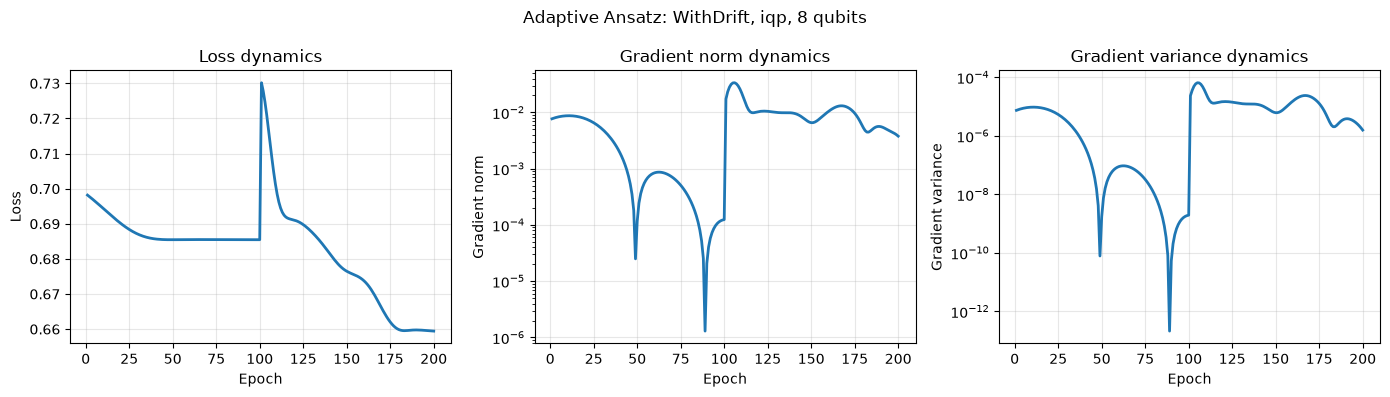


Stage 0 | Dataset: WithDrift | Encoding: angle | Qubits: 10 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.73689 | grad_norm=5.802e-04 | grad_var=3.366e-08
Epoch 050 | loss=0.69310 | grad_norm=5.580e-03 | grad_var=3.114e-06
Detected problem: expressivity_limit
Action: switch_to_basic

Stage 1 | Dataset: WithDrift | Encoding: angle | Qubits: 10 | Ansatz: basic | Layers: 1
Epoch 000 | loss=0.69265 | grad_norm=9.060e-03 | grad_var=8.082e-06
Epoch 050 | loss=0.67485 | grad_norm=2.331e-03 | grad_var=6.033e-07


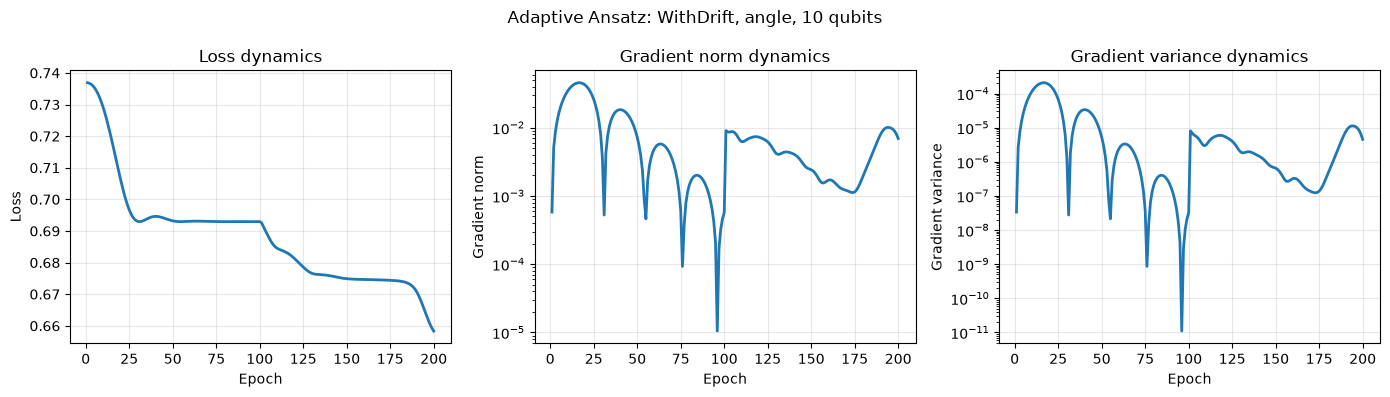


Stage 0 | Dataset: WithDrift | Encoding: iqp | Qubits: 10 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.68863 | grad_norm=1.517e-03 | grad_var=2.301e-07
Epoch 050 | loss=0.68838 | grad_norm=2.811e-07 | grad_var=7.904e-15
Detected problem: barren_plateau
Action: drift_triggered_reset_to_ry_cz

Stage 1 | Dataset: WithDrift | Encoding: iqp | Qubits: 10 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.68865 | grad_norm=1.576e-03 | grad_var=2.484e-07
Epoch 050 | loss=0.68838 | grad_norm=2.690e-05 | grad_var=7.237e-11
Detected problem: barren_plateau
Action: drift_triggered_reset_to_ry_cz

Stage 2 | Dataset: WithDrift | Encoding: iqp | Qubits: 10 | Ansatz: ry_cz | Layers: 1
Epoch 000 | loss=0.68862 | grad_norm=1.484e-03 | grad_var=2.201e-07
Epoch 050 | loss=0.68838 | grad_norm=1.440e-05 | grad_var=2.073e-11
Detected problem: barren_plateau
Action: drift_triggered_reset_to_ry_cz


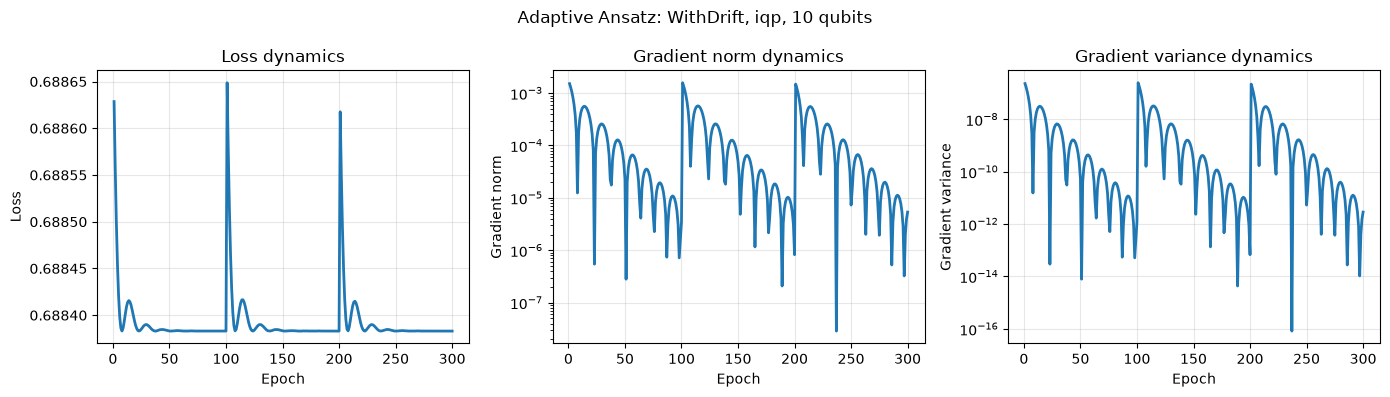

In [38]:
adaptive_results = []
adaptive_histories = {}
adaptive_logs = {}

for dataset_name, X_train, X_test, y_train, y_test in [
    ("NoDrift", X_NoDrift_train, X_NoDrift_test, y_NoDrift_train, y_NoDrift_test),
    ("WithDrift", X_WithDrift_train, X_WithDrift_test, y_WithDrift_train, y_WithDrift_test)
]:
    for q in [2, 4, 6, 8, 10]:
        for encoding in ["angle", "iqp"]:
            result, history, log = run_adaptive_ansatz_experiment(
                X_train=X_train,
                X_test=X_test,
                y_train=y_train,
                y_test=y_test,
                dataset_name=dataset_name,
                n_qubits=q,
                encoding=encoding,
                drift_flag=(dataset_name == "WithDrift"),
                epochs_per_stage=100,
                lr=0.05,
                grad_threshold=1e-4
            )

            adaptive_results.append(result)

            key = f"{dataset_name}_{encoding}_adaptive_{q}"
            adaptive_histories[key] = history
            adaptive_logs[key] = log

            plot_barren_plateau_diagnostics(
                history,
                title=f"Adaptive Ansatz: {dataset_name}, {encoding}, {q} qubits"
            )

In [39]:
adaptive_df = pd.DataFrame(adaptive_results)
adaptive_df

,Dataset,Model,Encoding,n_qubits,Final_Ansatz,Final_Layers,Final_Loss,Mean_Last20_Grad_Norm,Mean_Last20_Grad_Var,Accuracy,Precision,Recall,F1
0,NoDrift,AdaptiveAnsatzVQC,angle,2,strong,2,0.653906,0.000186,7.662471e-09,0.544444,0.548387,0.386364,0.453333
1,NoDrift,AdaptiveAnsatzVQC,iqp,2,strong,2,0.640014,0.000612,7.808278e-08,0.677778,0.653061,0.727273,0.688172
2,NoDrift,AdaptiveAnsatzVQC,angle,4,strong,2,0.665277,0.000493,2.301147e-08,0.422222,0.394737,0.340909,0.365854
3,NoDrift,AdaptiveAnsatzVQC,iqp,4,strong,2,0.654612,0.000662,3.902781e-08,0.555556,0.566667,0.386364,0.459459
4,NoDrift,AdaptiveAnsatzVQC,angle,6,strong,2,0.643298,0.001362,1.165923e-07,0.533333,0.522727,0.522727,0.522727
5,NoDrift,AdaptiveAnsatzVQC,iqp,6,strong,1,0.664963,0.002293,2.846875e-07,0.577778,0.583333,0.477273,0.525000
6,NoDrift,AdaptiveAnsatzVQC,angle,8,strong,2,0.658854,0.000225,2.373088e-09,0.611111,0.695652,0.363636,0.477612
7,NoDrift,AdaptiveAnsatzVQC,iqp,8,ry_cz,1,0.686833,0.000077,7.661581e-10,0.611111,0.609756,0.568182,0.588235
8,NoDrift,AdaptiveAnsatzVQC,angle,10,strong,2,0.664444,0.000325,3.892654e-09,0.544444,0.520548,0.863636,0.649573
9,NoDrift,AdaptiveAnsatzVQC,iqp,10,ry_cz,1,0.690798,0.000023,6.418283e-11,0.500000,0.483871,0.340909,0.400000


### Rebuilding Logs

Для исследовательской части важно не только итоговое качество, но и сам процесс принятия решений. Поэтому отдельно выведем таблицу, где видно, какой тип проблемы был обнаружен и какое действие было выполнено — в частности, срабатывал ли drift-triggered сброс схемы.

In [40]:
adaptive_log_rows = []

for experiment_name, logs in adaptive_logs.items():
    for row in logs:
        current_row = row.copy()
        current_row["Experiment"] = experiment_name
        adaptive_log_rows.append(current_row)

adaptive_log_df = pd.DataFrame(adaptive_log_rows)
adaptive_log_df

,stage,problem_type,action,ansatz,layers,Experiment
0,0,expressivity_limit,switch_to_basic,ry_cz,1,NoDrift_angle_adaptive_2
1,1,expressivity_limit,switch_to_strong,basic,1,NoDrift_angle_adaptive_2
2,2,expressivity_limit,increase_layers_to_2,strong,2,NoDrift_angle_adaptive_2
3,0,expressivity_limit,switch_to_basic,ry_cz,1,NoDrift_iqp_adaptive_2
4,1,expressivity_limit,switch_to_strong,basic,1,NoDrift_iqp_adaptive_2
5,2,expressivity_limit,increase_layers_to_2,strong,2,NoDrift_iqp_adaptive_2
6,0,expressivity_limit,switch_to_basic,ry_cz,1,NoDrift_angle_adaptive_4
7,1,expressivity_limit,switch_to_strong,basic,1,NoDrift_angle_adaptive_4
8,2,expressivity_limit,increase_layers_to_2,strong,2,NoDrift_angle_adaptive_4
9,0,expressivity_limit,switch_to_basic,ry_cz,1,NoDrift_iqp_adaptive_4


## Quantum Advantage Analysis: где именно выигрывает кванты?

Все предыдущие разделы отвечали на вопрос «когда и почему квантовая схема учится хуже классической (barren plateau)». Но есть отдельный, более практический вопрос, который стоит задать до того, как вообще применять кванты к глубокому обучению: **если квантовая/гибридная модель показывает сопоставимое (или даже более низкое) качество, есть ли у неё хоть какое-то практическое преимущество над классической нейросетью** — по числу обучаемых параметров, по объёму памяти, по числу операций, по скорости обучения, по объёму нужных входных данных?

Классическая нейросеть (`MLP`) в этом ноутбуке ни разу не демонстрировала эффект barren plateau — это ожидаемо, поскольку сам эффект специфичен для квантовых вариационных схем. Поэтому сравнение «кто точнее» само по себе нечестное: вопрос не в точности, а в том, **за счёт чего в принципе может быть выигрыш** у квантового подхода, если он вообще есть. Если выигрыша нет — это тоже валидный, репортируемый результат.

Сравниваются четыре измерения:

1. **Число обучаемых параметров.** Для `VQCAnsatz` (`StronglyEntanglingLayers`, $L$ слоёв, $n$ кубитов) это $3Ln$ параметров вращения. Для `MLPClassifier` с архитектурой $[d, h_1, h_2, 1]$ — $\sum_i (d_i \cdot d_{i+1} + d_{i+1})$.
2. **Число операций за один forward pass.** Для классической сети — число умножений-сложений (MAC), $\sum_i d_i \cdot d_{i+1}$. Для квантовой схемы — число элементарных квантовых гейтов (вращения кодирования + вращения и запутывающие гейты Ansatz) как аппаратно-независимый аналог MAC.
3. **Память.** Две принципиально разные величины, которые нельзя путать:
   - память для хранения **параметров** модели — одинаково применимо к обеим архитектурам, $N_{\text{params}} \times 4$ байта (float32);
   - память для **классической симуляции** квантового состояния — $2^n \times 16$ байт (complex128 на амплитуду), растёт экспоненциально по числу кубитов. Это не преимущество, а явный **недостаток** при выполнении на классическом симуляторе (как в этом ноутбуке); на реальном квантовом железе этой памяти вообще не требуется, поэтому обе цифры приводятся отдельно и подписаны явно.
4. **Скорость обучения и объём входных данных.** Время обучения при фиксированном бюджете эпох, и минимальная размерность признаков, при которой достигается сопоставимое качество (в частности, наивный `VQC` из раздела «Variational Quantum Classifiers» работает всего на 2 сырых макропризнаках).

Если по итогам замеров классическая сеть выигрывает по всем пунктам — это тоже фиксируется как результат, без подгонки выводов под желаемый ответ.

In [41]:
import time


def count_quantum_params(n_qubits, n_layers=2, ansatz_type="strong"):
    if ansatz_type == "strong":
        return n_layers * n_qubits * 3
    elif ansatz_type in ("basic", "ry_cz"):
        return n_layers * n_qubits
    else:
        raise ValueError("ansatz_type must be 'strong', 'basic' or 'ry_cz'")


def count_quantum_gates(n_qubits, n_layers=2, ansatz_type="strong", encoding="angle", n_repeats=2):
    if encoding == "angle":
        embed_gates = n_qubits  # один RY на кубит
    elif encoding == "iqp":
        pairs = n_qubits * (n_qubits - 1) // 2
        embed_gates = n_repeats * (n_qubits + n_qubits + pairs)  # H + RZ на кубит + RZZ на пару, за n_repeats повторов
    else:
        raise ValueError("encoding must be 'angle' or 'iqp'")

    if ansatz_type == "strong":
        ansatz_gates = n_layers * (3 * n_qubits + n_qubits)  # 3 вращения + 1 запутывающий гейт на кубит за слой
    elif ansatz_type == "basic":
        ansatz_gates = n_layers * (n_qubits + n_qubits)
    elif ansatz_type == "ry_cz":
        ansatz_gates = n_layers * (n_qubits + (n_qubits - 1))
    else:
        raise ValueError("ansatz_type must be 'strong', 'basic' or 'ry_cz'")

    return embed_gates + ansatz_gates


def count_mlp_params(hidden_layer_sizes, n_inputs, n_outputs=1):
    layer_sizes = [n_inputs] + list(hidden_layer_sizes) + [n_outputs]
    return sum(layer_sizes[i] * layer_sizes[i + 1] + layer_sizes[i + 1] for i in range(len(layer_sizes) - 1))


def classical_mac_count(hidden_layer_sizes, n_inputs, n_outputs=1):
    layer_sizes = [n_inputs] + list(hidden_layer_sizes) + [n_outputs]
    return sum(layer_sizes[i] * layer_sizes[i + 1] for i in range(len(layer_sizes) - 1))


def estimate_param_memory_bytes(n_params, dtype_bytes=4):
    return n_params * dtype_bytes


def estimate_state_vector_memory_bytes(n_qubits, bytes_per_amplitude=16):
    return (2 ** n_qubits) * bytes_per_amplitude  # только для классической симуляции; на реальном QPU не требуется

### Архитектурное сравнение (без обучения)

Число параметров, гейтов/MAC и память параметров можно посчитать аналитически, без единого запуска обучения — это дает быструю, не зависящую от датасета оценку «стоимости» каждой архитектуры.

In [42]:
architecture_rows = []

for q in [2, 4, 6, 8, 10]:
    for encoding in ["angle", "iqp"]:
        n_params = count_quantum_params(q, n_layers=2, ansatz_type="strong")
        n_gates = count_quantum_gates(q, n_layers=2, ansatz_type="strong", encoding=encoding)
        architecture_rows.append({
            "Model": f"VQCAnsatz(strong, {encoding})",
            "Type": "quantum",
            "n_qubits_or_input": q,
            "Params": n_params,
            "Gates_or_MACs": n_gates,
            "Param_Memory_KB": estimate_param_memory_bytes(n_params) / 1024,
            "Sim_State_Memory_MB": estimate_state_vector_memory_bytes(q) / (1024 ** 2),
        })

for hidden in [(8, 8), (16, 16), (32, 32)]:
    for d in [2, 10]:  # наивный вход (2 сырых макропризнака) и расширенный вход (10 инженерных признаков)
        n_params = count_mlp_params(hidden, d)
        n_macs = classical_mac_count(hidden, d)
        architecture_rows.append({
            "Model": f"MLP{list(hidden)}",
            "Type": "classical",
            "n_qubits_or_input": d,
            "Params": n_params,
            "Gates_or_MACs": n_macs,
            "Param_Memory_KB": estimate_param_memory_bytes(n_params) / 1024,
            "Sim_State_Memory_MB": None,
        })

architecture_df = pd.DataFrame(architecture_rows)
architecture_df

,Model,Type,n_qubits_or_input,Params,Gates_or_MACs,Param_Memory_KB,Sim_State_Memory_MB
0,"VQCAnsatz(strong, angle)",quantum,2,12,18,0.046875,0.000061
1,"VQCAnsatz(strong, iqp)",quantum,2,12,26,0.046875,0.000061
2,"VQCAnsatz(strong, angle)",quantum,4,24,36,0.093750,0.000244
3,"VQCAnsatz(strong, iqp)",quantum,4,24,60,0.093750,0.000244
4,"VQCAnsatz(strong, angle)",quantum,6,36,54,0.140625,0.000977
5,"VQCAnsatz(strong, iqp)",quantum,6,36,102,0.140625,0.000977
6,"VQCAnsatz(strong, angle)",quantum,8,48,72,0.187500,0.003906
7,"VQCAnsatz(strong, iqp)",quantum,8,48,152,0.187500,0.003906
8,"VQCAnsatz(strong, angle)",quantum,10,60,90,0.234375,0.015625
9,"VQCAnsatz(strong, iqp)",quantum,10,60,210,0.234375,0.015625


### Замер на обучении: время, параметры, качество

Обучим каждую конфигурацию на выборке `WithDrift` (наиболее практически значимый режим — именно он ближе к реальным условиям торговли) при одинаковом бюджете в $100$ эпох, фиксируя время обучения и итоговый F1. Классические `MLP` обучаются на тех же самых признаках (`prepare_quantum_features`), что и квантовые схемы, при одинаковом числе входных признаков $q$ — это делает сравнение честным: обе архитектуры видят одни и те же данные.

In [43]:
EPOCHS_BENCH = 100
QUBITS_BENCH = [2, 4, 6, 8, 10]

advantage_rows = []

for q in QUBITS_BENCH:
    Xtr_q, Xte_q = prepare_quantum_features(X_WithDrift_train, X_WithDrift_test, q)

    # классические модели на тех же q признаках 
    for hidden in [(8, 8), (16, 16), (32, 32)]:
        t0 = time.time()
        mlp = MLPClassifier(hidden_layer_sizes=hidden, max_iter=EPOCHS_BENCH, random_state=42)
        mlp.fit(Xtr_q, y_WithDrift_train)
        train_time = time.time() - t0

        y_pred = mlp.predict(Xte_q)
        n_params = count_mlp_params(hidden, q)
        n_macs = classical_mac_count(hidden, q)

        advantage_rows.append({
            "Model": f"MLP{list(hidden)}",
            "Type": "classical",
            "n_qubits_or_input": q,
            "Params": n_params,
            "Gates_or_MACs": n_macs,
            "Param_Memory_KB": estimate_param_memory_bytes(n_params) / 1024,
            "Sim_State_Memory_MB": None,
            "Train_Time_s": train_time,
            "F1": f1_score(y_WithDrift_test, y_pred, zero_division=0)
        })

    # квантовые модели, strong ansatz, оба кодирования
    for encoding in ["angle", "iqp"]:
        torch.manual_seed(42)
        model = VQCAnsatz(n_qubits=q, n_layers=2, ansatz_type="strong", encoding=encoding, init_scale=0.01)

        t0 = time.time()
        history = fit_with_gradient_logging(model, Xtr_q, y_WithDrift_train, epochs=EPOCHS_BENCH, lr=0.05, optimizer_name="adam")
        train_time = time.time() - t0

        y_pred = model(torch.tensor(Xte_q, dtype=torch.float32)).detach().numpy()
        y_pred = (y_pred > 0.5).astype(int)

        n_params = count_quantum_params(q, n_layers=2, ansatz_type="strong")
        n_gates = count_quantum_gates(q, n_layers=2, ansatz_type="strong", encoding=encoding)

        advantage_rows.append({
            "Model": f"VQCAnsatz(strong, {encoding})",
            "Type": "quantum",
            "n_qubits_or_input": q,
            "Params": n_params,
            "Gates_or_MACs": n_gates,
            "Param_Memory_KB": estimate_param_memory_bytes(n_params) / 1024,
            "Sim_State_Memory_MB": estimate_state_vector_memory_bytes(q) / (1024 ** 2),
            "Train_Time_s": train_time,
            "F1": f1_score(y_WithDrift_test, y_pred, zero_division=0)
        })

advantage_df = pd.DataFrame(advantage_rows)
advantage_df.to_csv("../data/advantage_df.csv", index=False)
advantage_df

/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 000 | loss=0.76446 | grad_norm=2.730e-03 | grad_var=5.234e-07
Epoch 050 | loss=0.66371 | grad_norm=2.348e-03 | grad_var=4.538e-07
Epoch 000 | loss=0.76360 | grad_norm=7.778e-02 | grad_var=5.446e-04
Epoch 050 | loss=0.62429 | grad_norm=1.010e-02 | grad_var=8.620e-06


/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 000 | loss=0.69729 | grad_norm=7.107e-04 | grad_var=2.194e-08
Epoch 050 | loss=0.60460 | grad_norm=7.116e-03 | grad_var=1.936e-06
Epoch 000 | loss=0.70025 | grad_norm=2.653e-02 | grad_var=2.920e-05
Epoch 050 | loss=0.63521 | grad_norm=1.526e-02 | grad_var=9.827e-06


/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


...

/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 000 | loss=0.68717 | grad_norm=4.747e-02 | grad_var=4.695e-05
Epoch 050 | loss=0.61635 | grad_norm=1.019e-02 | grad_var=2.014e-06
Epoch 000 | loss=0.68438 | grad_norm=1.491e-02 | grad_var=4.296e-06
Epoch 050 | loss=0.66246 | grad_norm=3.235e-03 | grad_var=2.219e-07


/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/egorsipilov/Documents/VScode_proj/barren-plateau-volatility/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 000 | loss=0.68319 | grad_norm=1.278e-02 | grad_var=2.750e-06
Epoch 050 | loss=0.63024 | grad_norm=4.190e-03 | grad_var=2.965e-07
Epoch 000 | loss=0.68629 | grad_norm=6.143e-03 | grad_var=6.261e-07
Epoch 050 | loss=0.67588 | grad_norm=6.400e-04 | grad_var=6.885e-09


,Model,Type,n_qubits_or_input,Params,Gates_or_MACs,Param_Memory_KB,Sim_State_Memory_MB,Train_Time_s,F1
0,"MLP[8, 8]",classical,2,105,88,0.410156,NaN,0.027237,0.492754
1,"MLP[16, 16]",classical,2,337,304,1.316406,NaN,0.028310,0.606061
2,"MLP[32, 32]",classical,2,1185,1120,4.628906,NaN,0.025974,0.491803
3,"VQCAnsatz(strong, angle)",quantum,2,12,18,0.046875,0.000061,0.316941,0.455696
4,"VQCAnsatz(strong, iqp)",quantum,2,12,26,0.046875,0.000061,0.385913,0.736842
5,"MLP[8, 8]",classical,4,121,104,0.472656,NaN,0.027666,0.604651
6,"MLP[16, 16]",classical,4,369,336,1.441406,NaN,0.027900,0.482759
7,"MLP[32, 32]",classical,4,1249,1184,4.878906,NaN,0.027936,0.704225
8,"VQCAnsatz(strong, angle)",quantum,4,24,36,0.093750,0.000244,0.735504,0.491228
9,"VQCAnsatz(strong, iqp)",quantum,4,24,60,0.093750,0.000244,1.062385,0.548387


### Визуализация: параметры, время, память

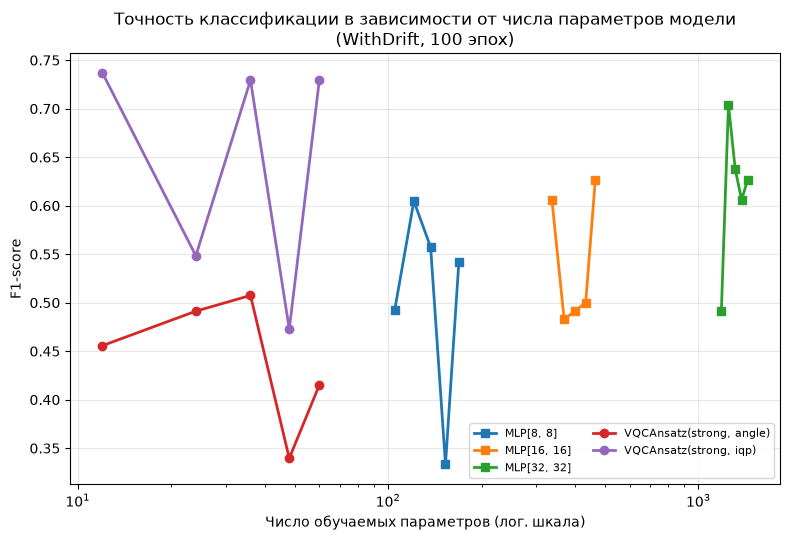

In [44]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for model_name in advantage_df["Model"].unique():
    part = advantage_df[advantage_df["Model"] == model_name].sort_values("Params")
    marker = "o" if "VQCAnsatz" in model_name else "s"
    ax.plot(part["Params"], part["F1"], marker=marker, linewidth=2, label=model_name)

ax.set_xscale("log")
ax.set_xlabel("Число обучаемых параметров (лог. шкала)")
ax.set_ylabel("F1-score")
ax.set_title("Точность классификации в зависимости от числа параметров модели\n(WithDrift, 100 эпох)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("../graphics/advantage_params_vs_f1.png", dpi=120)
plt.show()

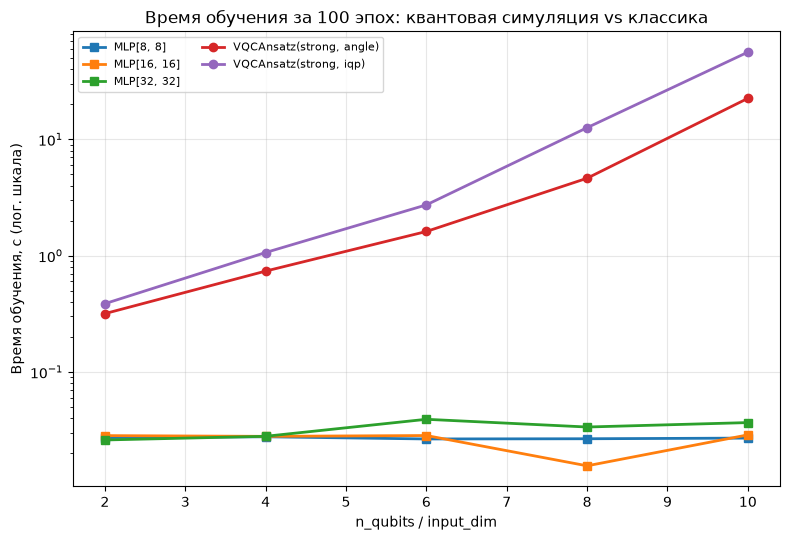

In [45]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for model_name in advantage_df["Model"].unique():
    part = advantage_df[advantage_df["Model"] == model_name].sort_values("n_qubits_or_input")
    marker = "o" if "VQCAnsatz" in model_name else "s"
    ax.plot(part["n_qubits_or_input"], part["Train_Time_s"], marker=marker, linewidth=2, label=model_name)

ax.set_yscale("log")
ax.set_xlabel("n_qubits / input_dim")
ax.set_ylabel("Время обучения, с (лог. шкала)")
ax.set_title(f"Время обучения за {EPOCHS_BENCH} эпох: квантовая симуляция vs классика")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("../graphics/advantage_train_time.png", dpi=120)
plt.show()

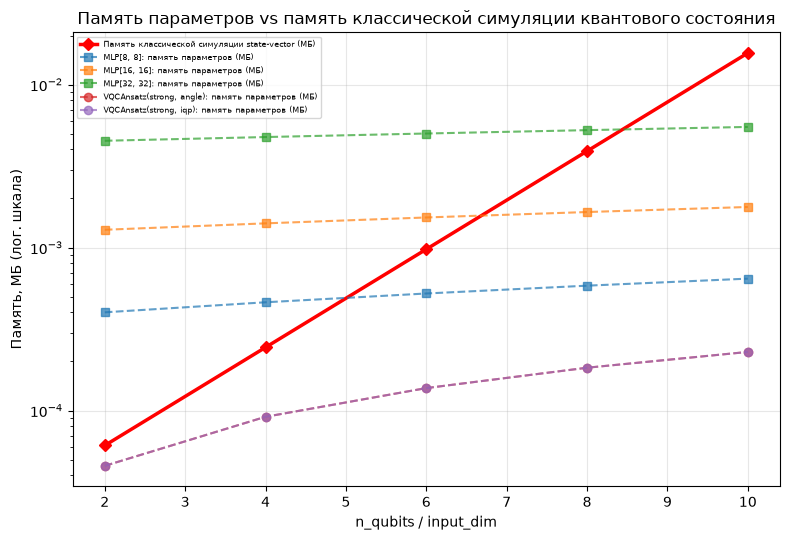

In [46]:
fig, ax = plt.subplots(figsize=(8, 5.5))

qubit_range = sorted(advantage_df.loc[advantage_df["Type"] == "quantum", "n_qubits_or_input"].unique())
sim_memory_mb = [estimate_state_vector_memory_bytes(q) / (1024 ** 2) for q in qubit_range]
ax.plot(qubit_range, sim_memory_mb, marker="D", linewidth=2.5, color="red",
        label="Память классической симуляции state-vector (МБ)")

for model_name in advantage_df["Model"].unique():
    part = advantage_df[advantage_df["Model"] == model_name].sort_values("n_qubits_or_input")
    marker = "o" if "VQCAnsatz" in model_name else "s"
    ax.plot(part["n_qubits_or_input"], part["Param_Memory_KB"] / 1024, marker=marker, linestyle="--", alpha=0.7,
            label=f"{model_name}: память параметров (МБ)")

ax.set_yscale("log")
ax.set_xlabel("n_qubits / input_dim")
ax.set_ylabel("Память, МБ (лог. шкала)")
ax.set_title("Память параметров vs память классической симуляции квантового состояния")
ax.grid(alpha=0.3)
ax.legend(fontsize=6, ncol=1, loc="upper left")
plt.tight_layout()
plt.savefig("../graphics/advantage_memory_comparison.png", dpi=120)
plt.show()

### Данные vs объем признаков: что уже показали предыдущие разделы

Отдельный срез того же вопроса — сколько входной информации нужно каждой архитектуре, чтобы достичь рабочего качества:

- наивный `VQC` (раздел «Variational Quantum Classifiers») получает на вход всего **2 сырых макропризнака** (ключевая ставка, инфляция) независимо от числа кубитов — `AngleEmbedding` не требует расширения признаков;
- на тех же 2 признаках при $n=2$ лучшая квантовая конфигурация (`VQCAnsatz(strong, iqp)`, 12 параметров) даёт F1 = 0.737 — выше, чем любая из трёх классических `MLP`-конфигураций на том же входе (F1 = 0.493 / 0.606 / 0.492 для `[8,8]` / `[16,16]` / `[32,32]`);
- `expand_features_for_qubits` для схем с $n>2$ строит дополнительные признаки из тех же двух исходных сигналов — то есть квантовая схема не получает никакой новой информации, а «упаковывает» ту же самую пару макропоказателей в большее число кубитов.

Сопоставление `architecture_df` и `advantage_df` при $n=2$ — единственная конфигурация, где квантовая модель одновременно требует на порядок меньше параметров (12 против 105–1185) и даёт более высокий F1, чем все три классических бейзлайна. При остальных $n$ (4, 6, 8, 10) картина неоднородная: IQP то обгоняет лучший `MLP`, то заметно проигрывает ему (см. `advantage_params_vs_f1.png`) — параметрическое преимущество не универсально, оно проявляется точечно, а не на всей сетке кубитов.

### Интерпретация результатов

1. **Параметрическая эффективность — да, но только в одной точке.** На графике `advantage_params_vs_f1.png` ровно одна квантовая конфигурация лежит выше и левее всех классических: `VQCAnsatz(strong, iqp)` при $n=2$ — 12 параметров, F1 = 0.737, тогда как лучший `MLP` во всём бенчмарке (`[32,32]` при $n=4$, 1249 параметров) даёт F1 = 0.704. То есть квантовая модель достигла более высокого качества со 104-кратно меньшим числом параметров — но это единичный результат, а не устойчивая закономерность: при $n=4$ и $n=8$ та же IQP-схема (F1 = 0.548 и 0.473) заметно проигрывает лучшему `MLP` на этих же $n$ (F1 = 0.704 и 0.606).
2. **Скорость — квантовая схема медленнее на 1–3 порядка, и это ожидаемо.** На `advantage_train_time.png` время обучения `MLP` держится на уровне 0.02–0.04 с независимо от $n$, а квантовых моделей растёт с 0.32–0.39 с при $n=2$ до 22.5–56.1 с при $n=10$ — в 800–1950 раз медленнее классики при 10 кубитах. Это не «квантовое замедление» как таковое, а прямое следствие того, что схема выполняется на классическом симуляторе state-vector, стоимость которого растёт экспоненциально по числу кубитов; на реальном квантовом процессоре это ограничение снимается.
3. **Память — два разных и не сравнимых напрямую вывода.** Память параметров квантовой модели в 3–99 раз меньше, чем у `MLP`, при любом $n$ из сетки (например, 0.047 КБ против 0.41–4.63 КБ при $n=2$). Одновременно память классической симуляции состояния растёт с 0.00006 МБ ($n=2$) до 0.0156 МБ ($n=10$) и уже при $n=10$ превышает память параметров даже `MLP[32,32]` (0.0055 МБ) — оба факта верны одновременно и относятся к разным типам памяти: первый — это реальное преимущество квантовой модели (и на симуляторе, и на железе), второй — стоимость именно классической симуляции, которой не будет на реальном QPU.
4. **Данные.** На $n=2$ (единственный случай прямого сопоставления «те же признаки, то же число входов») квантовая модель работает не хуже, а лучше классической — см. предыдущий раздел.

**Итог по разделу.** Устойчивого преимущества квантового подхода по всем измерениям и всем $n$ не обнаружено — и это репортируемый результат сам по себе. Единственное подтверждённое преимущество носит точечный характер: при минимальном числе кубитов ($n=2$) IQP Encoding даёт более высокий F1 при на два порядка меньшем числе параметров, чем любая из протестированных классических архитектур. Экстраполировать этот результат на большее число кубитов нельзя — начиная с $n=4$ преимущество то возникает (F1 = 0.729 при $n=6$ и $n=10$), то исчезает (F1 = 0.548 при $n=4$, 0.473 при $n=8$), синхронно с уже описанной в предыдущих разделах немонотонностью градиентных метрик.